<a href="https://colab.research.google.com/github/Rupya2012/standard_wallace/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LibreLane Colab

This Google Colab notebook will:
* Install LibreLane and its dependencies
* Run a simple design, namely a serial-parallel multiplier, through the flow
  and targeting the [open source sky130 PDK](https://github.com/google/skywater-pdk/)
  by Google and Skywater.

In [32]:
# @title Setup Nix {display-mode: "form"}
# @markdown <img src="https://raw.githubusercontent.com/NixOS/nixos-artwork/51a27e4a011e95cb559e37d32c44cf89b50f5154/logo/nix-snowflake-colours.svg" width="32"/>
# @markdown
# @markdown Nix is a package manager with an emphasis on reproducible builds,
# @markdown and it is the primary method for installing LibreLane.
# @markdown
# @markdown This step installs the Nix package manager and enables the
# @markdown FOSSi Foundation Nix Cache.
# @markdown
# @markdown If you're not in a Colab, this just sets the environment variables.
# @markdown You will need to install Nix and enable flakes on your own following
# @markdown [this guide](https://librelane.readthedocs.io/en/stable/getting_started/common/nix_installation/index.html).
import os
from pathlib import Path
import subprocess
import sys
import shutil
import tempfile

os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if "google.colab" in sys.modules:
    if shutil.which("nix-env") is None:
        with tempfile.TemporaryDirectory() as d:
            d = Path(d)
            installer_path = d / "nix"
            !curl --proto '=https' --tlsv1.2 -sSf -L https://install.determinate.systems/nix > {installer_path}
            with subprocess.Popen(
                [
                    "bash",
                    installer_path,
                    "install",
                    "--prefer-upstream-nix",
                    "--no-confirm",
                    "--extra-conf",
                    "extra-substituters = https://nix-cache.fossi-foundation.org\nextra-trusted-public-keys = nix-cache.fossi-foundation.org:3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n",
                ],
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                encoding="utf8",
            ) as p:
                for line in p.stdout:
                    print(line, end="")
else:
    if shutil.which("nix-env") is None:
        raise RuntimeError("Nix is not installed!")

os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"

In [33]:
# @title Get LibreLane {display-mode: "form"}
# @markdown Click the ▷ button to download and install LibreLane.
# @markdown
# @markdown This will install LibreLane's tool dependencies using Nix,
# @markdown and LibreLane itself using PIP.
# @markdown
# @markdown Note that `python3-tk` may need to be installed using your OS's
# @markdown package manager.
import os
import yaml
import subprocess
import IPython

librelane_version = "latest"  # @param {key:"LibreLane Version", type:"string"}

if librelane_version == "latest":
    librelane_version = "main"

pdk_root = "~/.ciel"  # @param {key:"PDK Root", type:"string"}

pdk_root = os.path.expanduser(pdk_root)

pdk = "sky130"  # @param {key:"PDK (without the variant)", type:"string"}

librelane_ipynb_path = os.path.join(os.getcwd(), "librelane_ipynb")

display(IPython.display.HTML("<h3>Downloading LibreLane…</a>"))


TESTING_LOCALLY = False
!rm -rf {librelane_ipynb_path}
!mkdir -p {librelane_ipynb_path}
if TESTING_LOCALLY:
    !ln -s {os.getcwd()} {librelane_ipynb_path}
else:
    !curl -L "https://github.com/librelane/librelane/tarball/{librelane_version}" | tar -xzC {librelane_ipynb_path} --strip-components 1

try:
    import tkinter
except ImportError:
    if "google.colab" in sys.modules:
        !sudo apt-get install python-tk

try:
    import tkinter
except ImportError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to import the <code>tkinter</code> library for Python, which is required to load PDK configuration values. Make sure <code>python3-tk</code> or equivalent is installed on your system.</a>'
        )
    )
    raise e from None


display(IPython.display.HTML("<h3>Downloading LibreLane's dependencies…</a>"))
try:
    with subprocess.Popen(
        [
            "nix",
            "profile",
            "install",
            ".#colab-env",
        ],
        cwd=librelane_ipynb_path,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        encoding="utf8",
    ) as p:
        for line in p.stdout:
            print(line, end="")
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install binary dependencies using Nix…</h3>'
        )
    )

display(IPython.display.HTML("<h3>Downloading Python dependencies using PIP…</a>"))
try:
    subprocess.check_call(
        ["pip3", "install", "."],
        cwd=librelane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install Python dependencies using PIP…</h3>'
        )
    )
    raise e from None

display(IPython.display.HTML("<h3>Downloading PDK…</a>"))
import ciel
from ciel.source import StaticWebDataSource

with open(
    os.path.join(librelane_ipynb_path, "librelane", "pdk_hashes.yaml"), "r"
) as file:
    pdk_hashes = yaml.safe_load(file)

ciel.enable(
    ciel.get_ciel_home(pdk_root),
    pdk,
    pdk_hashes[pdk],
    data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"),
)

sys.path.insert(0, librelane_ipynb_path)
display(IPython.display.HTML("<h3>⭕️ Done.</a>"))

import logging

# Remove the stupid default colab logging handler
logging.getLogger().handlers.clear()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 8901k    0 8901k    0     0  9174k      0 --:--:-- --:--:-- --:--:-- 21.3M


Version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71 enabled for the sky130 PDK.

In [34]:
import librelane

print(librelane.__version__)

3.0.3


### Creating the design

Now that LibreLane is set up, we can write a Verilog file as follows:

In [35]:
%%writefile spm.v
`default_nettype none
module spm(
    input  [15:0] a,
    input  [15:0] b,
    output  [31:0] sum
);
wire [31:0] row0;
wire [31:0] row1 ;
wire pp_0_0, pp_0_1, pp_0_2, pp_0_3, pp_0_4, pp_0_5, pp_0_6, pp_0_7;
wire pp_0_8, pp_0_9, pp_0_10, pp_0_11, pp_0_12, pp_0_13, pp_0_14, pp_0_15;
wire pp_1_0, pp_1_1, pp_1_2, pp_1_3, pp_1_4, pp_1_5, pp_1_6, pp_1_7;
wire pp_1_8, pp_1_9, pp_1_10, pp_1_11, pp_1_12, pp_1_13, pp_1_14, pp_1_15;
wire pp_2_0, pp_2_1, pp_2_2, pp_2_3, pp_2_4, pp_2_5, pp_2_6, pp_2_7;
wire pp_2_8, pp_2_9, pp_2_10, pp_2_11, pp_2_12, pp_2_13, pp_2_14, pp_2_15;
wire pp_3_0, pp_3_1, pp_3_2, pp_3_3, pp_3_4, pp_3_5, pp_3_6, pp_3_7;
wire pp_3_8, pp_3_9, pp_3_10, pp_3_11, pp_3_12, pp_3_13, pp_3_14, pp_3_15;
wire pp_4_0, pp_4_1, pp_4_2, pp_4_3, pp_4_4, pp_4_5, pp_4_6, pp_4_7;
wire pp_4_8, pp_4_9, pp_4_10, pp_4_11, pp_4_12, pp_4_13, pp_4_14, pp_4_15;
wire pp_5_0, pp_5_1, pp_5_2, pp_5_3, pp_5_4, pp_5_5, pp_5_6, pp_5_7;
wire pp_5_8, pp_5_9, pp_5_10, pp_5_11, pp_5_12, pp_5_13, pp_5_14, pp_5_15;
wire pp_6_0, pp_6_1, pp_6_2, pp_6_3, pp_6_4, pp_6_5, pp_6_6, pp_6_7;
wire pp_6_8, pp_6_9, pp_6_10, pp_6_11, pp_6_12, pp_6_13, pp_6_14, pp_6_15;
wire pp_7_0, pp_7_1, pp_7_2, pp_7_3, pp_7_4, pp_7_5, pp_7_6, pp_7_7;
wire pp_7_8, pp_7_9, pp_7_10, pp_7_11, pp_7_12, pp_7_13, pp_7_14, pp_7_15;
wire pp_8_0, pp_8_1, pp_8_2, pp_8_3, pp_8_4, pp_8_5, pp_8_6, pp_8_7;
wire pp_8_8, pp_8_9, pp_8_10, pp_8_11, pp_8_12, pp_8_13, pp_8_14, pp_8_15;
wire pp_9_0, pp_9_1, pp_9_2, pp_9_3, pp_9_4, pp_9_5, pp_9_6, pp_9_7;
wire pp_9_8, pp_9_9, pp_9_10, pp_9_11, pp_9_12, pp_9_13, pp_9_14, pp_9_15;
wire pp_10_0, pp_10_1, pp_10_2, pp_10_3, pp_10_4, pp_10_5, pp_10_6, pp_10_7;
wire pp_10_8, pp_10_9, pp_10_10, pp_10_11, pp_10_12, pp_10_13, pp_10_14, pp_10_15;
wire pp_11_0, pp_11_1, pp_11_2, pp_11_3, pp_11_4, pp_11_5, pp_11_6, pp_11_7;
wire pp_11_8, pp_11_9, pp_11_10, pp_11_11, pp_11_12, pp_11_13, pp_11_14, pp_11_15;
wire pp_12_0, pp_12_1, pp_12_2, pp_12_3, pp_12_4, pp_12_5, pp_12_6, pp_12_7;
wire pp_12_8, pp_12_9, pp_12_10, pp_12_11, pp_12_12, pp_12_13, pp_12_14, pp_12_15;
wire pp_13_0, pp_13_1, pp_13_2, pp_13_3, pp_13_4, pp_13_5, pp_13_6, pp_13_7;
wire pp_13_8, pp_13_9, pp_13_10, pp_13_11, pp_13_12, pp_13_13, pp_13_14, pp_13_15;
wire pp_14_0, pp_14_1, pp_14_2, pp_14_3, pp_14_4, pp_14_5, pp_14_6, pp_14_7;
wire pp_14_8, pp_14_9, pp_14_10, pp_14_11, pp_14_12, pp_14_13, pp_14_14, pp_14_15;
wire pp_15_0, pp_15_1, pp_15_2, pp_15_3, pp_15_4, pp_15_5, pp_15_6, pp_15_7;
wire pp_15_8, pp_15_9, pp_15_10, pp_15_11, pp_15_12, pp_15_13, pp_15_14, pp_15_15;
wire s0_c10_22_c_0, s0_c10_22_s_0, s0_c10_32_c_0, s0_c10_32_c_1, s0_c10_32_c_2, s0_c10_32_s_0, s0_c10_32_s_1, s0_c10_32_s_2;
wire s0_c11_32_c_0, s0_c11_32_c_1, s0_c11_32_c_2, s0_c11_32_c_3, s0_c11_32_s_0, s0_c11_32_s_1, s0_c11_32_s_2, s0_c11_32_s_3;
wire s0_c12_32_c_0, s0_c12_32_c_1, s0_c12_32_c_2, s0_c12_32_c_3, s0_c12_32_s_0, s0_c12_32_s_1, s0_c12_32_s_2, s0_c12_32_s_3;
wire s0_c13_22_c_0, s0_c13_22_s_0, s0_c13_32_c_0, s0_c13_32_c_1, s0_c13_32_c_2, s0_c13_32_c_3, s0_c13_32_s_0, s0_c13_32_s_1;
wire s0_c13_32_s_2, s0_c13_32_s_3, s0_c14_32_c_0, s0_c14_32_c_1, s0_c14_32_c_2, s0_c14_32_c_3, s0_c14_32_c_4, s0_c14_32_s_0;
wire s0_c14_32_s_1, s0_c14_32_s_2, s0_c14_32_s_3, s0_c14_32_s_4, s0_c15_32_c_0, s0_c15_32_c_1, s0_c15_32_c_2, s0_c15_32_c_3;
wire s0_c15_32_c_4, s0_c15_32_s_0, s0_c15_32_s_1, s0_c15_32_s_2, s0_c15_32_s_3, s0_c15_32_s_4, s0_c16_32_c_0, s0_c16_32_c_1;
wire s0_c16_32_c_2, s0_c16_32_c_3, s0_c16_32_c_4, s0_c16_32_s_0, s0_c16_32_s_1, s0_c16_32_s_2, s0_c16_32_s_3, s0_c16_32_s_4;
wire s0_c17_22_c_0, s0_c17_22_s_0, s0_c17_32_c_0, s0_c17_32_c_1, s0_c17_32_c_2, s0_c17_32_c_3, s0_c17_32_s_0, s0_c17_32_s_1;
wire s0_c17_32_s_2, s0_c17_32_s_3, s0_c18_32_c_0, s0_c18_32_c_1, s0_c18_32_c_2, s0_c18_32_c_3, s0_c18_32_s_0, s0_c18_32_s_1;
wire s0_c18_32_s_2, s0_c18_32_s_3, s0_c19_32_c_0, s0_c19_32_c_1, s0_c19_32_c_2, s0_c19_32_c_3, s0_c19_32_s_0, s0_c19_32_s_1;
wire s0_c19_32_s_2, s0_c19_32_s_3, s0_c20_22_c_0, s0_c20_22_s_0, s0_c20_32_c_0, s0_c20_32_c_1, s0_c20_32_c_2, s0_c20_32_s_0;
wire s0_c20_32_s_1, s0_c20_32_s_2, s0_c21_32_c_0, s0_c21_32_c_1, s0_c21_32_c_2, s0_c21_32_s_0, s0_c21_32_s_1, s0_c21_32_s_2;
wire s0_c22_32_c_0, s0_c22_32_c_1, s0_c22_32_c_2, s0_c22_32_s_0, s0_c22_32_s_1, s0_c22_32_s_2, s0_c23_22_c_0, s0_c23_22_s_0;
wire s0_c23_32_c_0, s0_c23_32_c_1, s0_c23_32_s_0, s0_c23_32_s_1, s0_c24_32_c_0, s0_c24_32_c_1, s0_c24_32_s_0, s0_c24_32_s_1;
wire s0_c25_32_c_0, s0_c25_32_c_1, s0_c25_32_s_0, s0_c25_32_s_1, s0_c26_22_c_0, s0_c26_22_s_0, s0_c26_32_c_0, s0_c26_32_s_0;
wire s0_c27_32_c_0, s0_c27_32_s_0, s0_c28_32_c_0, s0_c28_32_s_0, s0_c29_22_c_0, s0_c29_22_s_0, s0_c2_32_c_0, s0_c2_32_s_0;
wire s0_c3_32_c_0, s0_c3_32_s_0, s0_c4_22_c_0, s0_c4_22_s_0, s0_c4_32_c_0, s0_c4_32_s_0, s0_c5_32_c_0, s0_c5_32_c_1;
wire s0_c5_32_s_0, s0_c5_32_s_1, s0_c6_32_c_0, s0_c6_32_c_1, s0_c6_32_s_0, s0_c6_32_s_1, s0_c7_22_c_0, s0_c7_22_s_0;
wire s0_c7_32_c_0, s0_c7_32_c_1, s0_c7_32_s_0, s0_c7_32_s_1, s0_c8_32_c_0, s0_c8_32_c_1, s0_c8_32_c_2, s0_c8_32_s_0;
wire s0_c8_32_s_1, s0_c8_32_s_2, s0_c9_32_c_0, s0_c9_32_c_1, s0_c9_32_c_2, s0_c9_32_s_0, s0_c9_32_s_1, s0_c9_32_s_2;
wire s1_c10_32_c_0, s1_c10_32_c_1, s1_c10_32_s_0, s1_c10_32_s_1, s1_c11_22_c_0, s1_c11_22_s_0, s1_c11_32_c_0, s1_c11_32_c_1;
wire s1_c11_32_s_0, s1_c11_32_s_1, s1_c12_32_c_0, s1_c12_32_c_1, s1_c12_32_c_2, s1_c12_32_s_0, s1_c12_32_s_1, s1_c12_32_s_2;
wire s1_c13_32_c_0, s1_c13_32_c_1, s1_c13_32_c_2, s1_c13_32_s_0, s1_c13_32_s_1, s1_c13_32_s_2, s1_c14_32_c_0, s1_c14_32_c_1;
wire s1_c14_32_c_2, s1_c14_32_s_0, s1_c14_32_s_1, s1_c14_32_s_2, s1_c15_22_c_0, s1_c15_22_s_0, s1_c15_32_c_0, s1_c15_32_c_1;
wire s1_c15_32_c_2, s1_c15_32_s_0, s1_c15_32_s_1, s1_c15_32_s_2, s1_c16_32_c_0, s1_c16_32_c_1, s1_c16_32_c_2, s1_c16_32_s_0;
wire s1_c16_32_s_1, s1_c16_32_s_2, s1_c17_32_c_0, s1_c17_32_c_1, s1_c17_32_c_2, s1_c17_32_s_0, s1_c17_32_s_1, s1_c17_32_s_2;
wire s1_c18_32_c_0, s1_c18_32_c_1, s1_c18_32_c_2, s1_c18_32_s_0, s1_c18_32_s_1, s1_c18_32_s_2, s1_c19_22_c_0, s1_c19_22_s_0;
wire s1_c19_32_c_0, s1_c19_32_c_1, s1_c19_32_s_0, s1_c19_32_s_1, s1_c20_22_c_0, s1_c20_22_s_0, s1_c20_32_c_0, s1_c20_32_c_1;
wire s1_c20_32_s_0, s1_c20_32_s_1, s1_c21_22_c_0, s1_c21_22_s_0, s1_c21_32_c_0, s1_c21_32_c_1, s1_c21_32_s_0, s1_c21_32_s_1;
wire s1_c22_32_c_0, s1_c22_32_c_1, s1_c22_32_s_0, s1_c22_32_s_1, s1_c23_32_c_0, s1_c23_32_c_1, s1_c23_32_s_0, s1_c23_32_s_1;
wire s1_c24_32_c_0, s1_c24_32_c_1, s1_c24_32_s_0, s1_c24_32_s_1, s1_c25_32_c_0, s1_c25_32_s_0, s1_c26_32_c_0, s1_c26_32_s_0;
wire s1_c27_32_c_0, s1_c27_32_s_0, s1_c28_22_c_0, s1_c28_22_s_0, s1_c29_22_c_0, s1_c29_22_s_0, s1_c30_22_c_0, s1_c30_22_s_0;
wire s1_c3_32_c_0, s1_c3_32_s_0, s1_c4_32_c_0, s1_c4_32_s_0, s1_c5_32_c_0, s1_c5_32_s_0, s1_c6_22_c_0, s1_c6_22_s_0;
wire s1_c6_32_c_0, s1_c6_32_s_0, s1_c7_22_c_0, s1_c7_22_s_0, s1_c7_32_c_0, s1_c7_32_s_0, s1_c8_32_c_0, s1_c8_32_c_1;
wire s1_c8_32_s_0, s1_c8_32_s_1, s1_c9_32_c_0, s1_c9_32_c_1, s1_c9_32_s_0, s1_c9_32_s_1, s2_c10_22_c_0, s2_c10_22_s_0;
wire s2_c10_32_c_0, s2_c10_32_s_0, s2_c11_22_c_0, s2_c11_22_s_0, s2_c11_32_c_0, s2_c11_32_s_0, s2_c12_32_c_0, s2_c12_32_c_1;
wire s2_c12_32_s_0, s2_c12_32_s_1, s2_c13_32_c_0, s2_c13_32_c_1, s2_c13_32_s_0, s2_c13_32_s_1, s2_c14_32_c_0, s2_c14_32_c_1;
wire s2_c14_32_s_0, s2_c14_32_s_1, s2_c15_32_c_0, s2_c15_32_c_1, s2_c15_32_s_0, s2_c15_32_s_1, s2_c16_22_c_0, s2_c16_22_s_0;
wire s2_c16_32_c_0, s2_c16_32_c_1, s2_c16_32_s_0, s2_c16_32_s_1, s2_c17_32_c_0, s2_c17_32_c_1, s2_c17_32_s_0, s2_c17_32_s_1;
wire s2_c18_32_c_0, s2_c18_32_c_1, s2_c18_32_s_0, s2_c18_32_s_1, s2_c19_32_c_0, s2_c19_32_c_1, s2_c19_32_s_0, s2_c19_32_s_1;
wire s2_c20_32_c_0, s2_c20_32_c_1, s2_c20_32_s_0, s2_c20_32_s_1, s2_c21_32_c_0, s2_c21_32_c_1, s2_c21_32_s_0, s2_c21_32_s_1;
wire s2_c22_22_c_0, s2_c22_22_s_0, s2_c22_32_c_0, s2_c22_32_s_0, s2_c23_32_c_0, s2_c23_32_s_0, s2_c24_32_c_0, s2_c24_32_s_0;
wire s2_c25_32_c_0, s2_c25_32_s_0, s2_c26_32_c_0, s2_c26_32_s_0, s2_c27_32_c_0, s2_c27_32_s_0, s2_c28_22_c_0, s2_c28_22_s_0;
wire s2_c29_22_c_0, s2_c29_22_s_0, s2_c30_22_c_0, s2_c30_22_s_0, s2_c5_32_c_0, s2_c5_32_s_0, s2_c6_32_c_0, s2_c6_32_s_0;
wire s2_c7_32_c_0, s2_c7_32_s_0, s2_c8_32_c_0, s2_c8_32_s_0, s2_c9_22_c_0, s2_c9_22_s_0, s2_c9_32_c_0, s2_c9_32_s_0;
wire s3_c10_32_c_0, s3_c10_32_s_0, s3_c11_32_c_0, s3_c11_32_s_0, s3_c12_32_c_0, s3_c12_32_s_0, s3_c13_32_c_0, s3_c13_32_s_0;
wire s3_c14_22_c_0, s3_c14_22_s_0, s3_c14_32_c_0, s3_c14_32_s_0, s3_c15_22_c_0, s3_c15_22_s_0, s3_c15_32_c_0, s3_c15_32_s_0;
wire s3_c16_22_c_0, s3_c16_22_s_0, s3_c16_32_c_0, s3_c16_32_s_0, s3_c17_32_c_0, s3_c17_32_c_1, s3_c17_32_s_0, s3_c17_32_s_1;
wire s3_c18_22_c_0, s3_c18_22_s_0, s3_c18_32_c_0, s3_c18_32_s_0, s3_c19_32_c_0, s3_c19_32_s_0, s3_c20_32_c_0, s3_c20_32_s_0;
wire s3_c21_32_c_0, s3_c21_32_s_0, s3_c22_32_c_0, s3_c22_32_s_0, s3_c23_32_c_0, s3_c23_32_s_0, s3_c24_32_c_0, s3_c24_32_s_0;
wire s3_c25_32_c_0, s3_c25_32_s_0, s3_c26_22_c_0, s3_c26_22_s_0, s3_c27_22_c_0, s3_c27_22_s_0, s3_c28_22_c_0, s3_c28_22_s_0;
wire s3_c29_22_c_0, s3_c29_22_s_0, s3_c30_22_c_0, s3_c30_22_s_0, s3_c31_22_c_0, s3_c31_22_s_0, s3_c7_32_c_0, s3_c7_32_s_0;
wire s3_c8_32_c_0, s3_c8_32_s_0, s3_c9_32_c_0, s3_c9_32_s_0, s4_c10_32_c_0, s4_c10_32_s_0, s4_c11_32_c_0, s4_c11_32_s_0;
wire s4_c12_32_c_0, s4_c12_32_s_0, s4_c13_32_c_0, s4_c13_32_s_0, s4_c14_32_c_0, s4_c14_32_s_0, s4_c15_32_c_0, s4_c15_32_s_0;
wire s4_c16_32_c_0, s4_c16_32_s_0, s4_c17_32_c_0, s4_c17_32_s_0, s4_c18_32_c_0, s4_c18_32_s_0, s4_c19_32_c_0, s4_c19_32_s_0;
wire s4_c20_32_c_0, s4_c20_32_s_0, s4_c21_32_c_0, s4_c21_32_s_0, s4_c22_32_c_0, s4_c22_32_s_0, s4_c23_32_c_0, s4_c23_32_s_0;
wire s4_c24_22_c_0, s4_c24_22_s_0, s4_c25_22_c_0, s4_c25_22_s_0, s4_c26_22_c_0, s4_c26_22_s_0, s4_c27_22_c_0, s4_c27_22_s_0;
wire s4_c28_22_c_0, s4_c28_22_s_0, s4_c29_22_c_0, s4_c29_22_s_0, s4_c30_22_c_0, s4_c30_22_s_0, s4_c31_22_c_0, s4_c31_22_s_0;
wire s5_c15_32_c_0, s5_c15_32_s_0, s5_c16_32_c_0, s5_c16_32_s_0, s5_c17_32_c_0, s5_c17_32_s_0, s5_c18_32_c_0, s5_c18_32_s_0;
wire s5_c19_32_c_0, s5_c19_32_s_0, s5_c20_22_c_0, s5_c20_22_s_0, s5_c21_22_c_0, s5_c21_22_s_0, s5_c22_22_c_0, s5_c22_22_s_0;
wire s5_c23_22_c_0, s5_c23_22_s_0, s5_c24_22_c_0, s5_c24_22_s_0, s5_c25_22_c_0, s5_c25_22_s_0, s5_c26_22_c_0, s5_c26_22_s_0;
wire s5_c27_22_c_0, s5_c27_22_s_0, s5_c28_22_c_0, s5_c28_22_s_0, s5_c29_22_c_0, s5_c29_22_s_0, s5_c30_22_c_0, s5_c30_22_s_0;
wire s5_c31_22_c_0, s5_c31_22_s_0, s5_c32_22_c_0, s5_c32_22_s_0;

assign pp_0_0 = a[0] & b[0];
assign pp_0_1 = a[0] & b[1];
assign pp_0_2 = a[0] & b[2];
assign pp_0_3 = a[0] & b[3];
assign pp_0_4 = a[0] & b[4];
assign pp_0_5 = a[0] & b[5];
assign pp_0_6 = a[0] & b[6];
assign pp_0_7 = a[0] & b[7];
assign pp_0_8 = a[0] & b[8];
assign pp_0_9 = a[0] & b[9];
assign pp_0_10 = a[0] & b[10];
assign pp_0_11 = a[0] & b[11];
assign pp_0_12 = a[0] & b[12];
assign pp_0_13 = a[0] & b[13];
assign pp_0_14 = a[0] & b[14];
assign pp_0_15 = a[0] & b[15];
assign pp_1_0 = a[1] & b[0];
assign pp_1_1 = a[1] & b[1];
assign pp_1_2 = a[1] & b[2];
assign pp_1_3 = a[1] & b[3];
assign pp_1_4 = a[1] & b[4];
assign pp_1_5 = a[1] & b[5];
assign pp_1_6 = a[1] & b[6];
assign pp_1_7 = a[1] & b[7];
assign pp_1_8 = a[1] & b[8];
assign pp_1_9 = a[1] & b[9];
assign pp_1_10 = a[1] & b[10];
assign pp_1_11 = a[1] & b[11];
assign pp_1_12 = a[1] & b[12];
assign pp_1_13 = a[1] & b[13];
assign pp_1_14 = a[1] & b[14];
assign pp_1_15 = a[1] & b[15];
assign pp_2_0 = a[2] & b[0];
assign pp_2_1 = a[2] & b[1];
assign pp_2_2 = a[2] & b[2];
assign pp_2_3 = a[2] & b[3];
assign pp_2_4 = a[2] & b[4];
assign pp_2_5 = a[2] & b[5];
assign pp_2_6 = a[2] & b[6];
assign pp_2_7 = a[2] & b[7];
assign pp_2_8 = a[2] & b[8];
assign pp_2_9 = a[2] & b[9];
assign pp_2_10 = a[2] & b[10];
assign pp_2_11 = a[2] & b[11];
assign pp_2_12 = a[2] & b[12];
assign pp_2_13 = a[2] & b[13];
assign pp_2_14 = a[2] & b[14];
assign pp_2_15 = a[2] & b[15];
assign pp_3_0 = a[3] & b[0];
assign pp_3_1 = a[3] & b[1];
assign pp_3_2 = a[3] & b[2];
assign pp_3_3 = a[3] & b[3];
assign pp_3_4 = a[3] & b[4];
assign pp_3_5 = a[3] & b[5];
assign pp_3_6 = a[3] & b[6];
assign pp_3_7 = a[3] & b[7];
assign pp_3_8 = a[3] & b[8];
assign pp_3_9 = a[3] & b[9];
assign pp_3_10 = a[3] & b[10];
assign pp_3_11 = a[3] & b[11];
assign pp_3_12 = a[3] & b[12];
assign pp_3_13 = a[3] & b[13];
assign pp_3_14 = a[3] & b[14];
assign pp_3_15 = a[3] & b[15];
assign pp_4_0 = a[4] & b[0];
assign pp_4_1 = a[4] & b[1];
assign pp_4_2 = a[4] & b[2];
assign pp_4_3 = a[4] & b[3];
assign pp_4_4 = a[4] & b[4];
assign pp_4_5 = a[4] & b[5];
assign pp_4_6 = a[4] & b[6];
assign pp_4_7 = a[4] & b[7];
assign pp_4_8 = a[4] & b[8];
assign pp_4_9 = a[4] & b[9];
assign pp_4_10 = a[4] & b[10];
assign pp_4_11 = a[4] & b[11];
assign pp_4_12 = a[4] & b[12];
assign pp_4_13 = a[4] & b[13];
assign pp_4_14 = a[4] & b[14];
assign pp_4_15 = a[4] & b[15];
assign pp_5_0 = a[5] & b[0];
assign pp_5_1 = a[5] & b[1];
assign pp_5_2 = a[5] & b[2];
assign pp_5_3 = a[5] & b[3];
assign pp_5_4 = a[5] & b[4];
assign pp_5_5 = a[5] & b[5];
assign pp_5_6 = a[5] & b[6];
assign pp_5_7 = a[5] & b[7];
assign pp_5_8 = a[5] & b[8];
assign pp_5_9 = a[5] & b[9];
assign pp_5_10 = a[5] & b[10];
assign pp_5_11 = a[5] & b[11];
assign pp_5_12 = a[5] & b[12];
assign pp_5_13 = a[5] & b[13];
assign pp_5_14 = a[5] & b[14];
assign pp_5_15 = a[5] & b[15];
assign pp_6_0 = a[6] & b[0];
assign pp_6_1 = a[6] & b[1];
assign pp_6_2 = a[6] & b[2];
assign pp_6_3 = a[6] & b[3];
assign pp_6_4 = a[6] & b[4];
assign pp_6_5 = a[6] & b[5];
assign pp_6_6 = a[6] & b[6];
assign pp_6_7 = a[6] & b[7];
assign pp_6_8 = a[6] & b[8];
assign pp_6_9 = a[6] & b[9];
assign pp_6_10 = a[6] & b[10];
assign pp_6_11 = a[6] & b[11];
assign pp_6_12 = a[6] & b[12];
assign pp_6_13 = a[6] & b[13];
assign pp_6_14 = a[6] & b[14];
assign pp_6_15 = a[6] & b[15];
assign pp_7_0 = a[7] & b[0];
assign pp_7_1 = a[7] & b[1];
assign pp_7_2 = a[7] & b[2];
assign pp_7_3 = a[7] & b[3];
assign pp_7_4 = a[7] & b[4];
assign pp_7_5 = a[7] & b[5];
assign pp_7_6 = a[7] & b[6];
assign pp_7_7 = a[7] & b[7];
assign pp_7_8 = a[7] & b[8];
assign pp_7_9 = a[7] & b[9];
assign pp_7_10 = a[7] & b[10];
assign pp_7_11 = a[7] & b[11];
assign pp_7_12 = a[7] & b[12];
assign pp_7_13 = a[7] & b[13];
assign pp_7_14 = a[7] & b[14];
assign pp_7_15 = a[7] & b[15];
assign pp_8_0 = a[8] & b[0];
assign pp_8_1 = a[8] & b[1];
assign pp_8_2 = a[8] & b[2];
assign pp_8_3 = a[8] & b[3];
assign pp_8_4 = a[8] & b[4];
assign pp_8_5 = a[8] & b[5];
assign pp_8_6 = a[8] & b[6];
assign pp_8_7 = a[8] & b[7];
assign pp_8_8 = a[8] & b[8];
assign pp_8_9 = a[8] & b[9];
assign pp_8_10 = a[8] & b[10];
assign pp_8_11 = a[8] & b[11];
assign pp_8_12 = a[8] & b[12];
assign pp_8_13 = a[8] & b[13];
assign pp_8_14 = a[8] & b[14];
assign pp_8_15 = a[8] & b[15];
assign pp_9_0 = a[9] & b[0];
assign pp_9_1 = a[9] & b[1];
assign pp_9_2 = a[9] & b[2];
assign pp_9_3 = a[9] & b[3];
assign pp_9_4 = a[9] & b[4];
assign pp_9_5 = a[9] & b[5];
assign pp_9_6 = a[9] & b[6];
assign pp_9_7 = a[9] & b[7];
assign pp_9_8 = a[9] & b[8];
assign pp_9_9 = a[9] & b[9];
assign pp_9_10 = a[9] & b[10];
assign pp_9_11 = a[9] & b[11];
assign pp_9_12 = a[9] & b[12];
assign pp_9_13 = a[9] & b[13];
assign pp_9_14 = a[9] & b[14];
assign pp_9_15 = a[9] & b[15];
assign pp_10_0 = a[10] & b[0];
assign pp_10_1 = a[10] & b[1];
assign pp_10_2 = a[10] & b[2];
assign pp_10_3 = a[10] & b[3];
assign pp_10_4 = a[10] & b[4];
assign pp_10_5 = a[10] & b[5];
assign pp_10_6 = a[10] & b[6];
assign pp_10_7 = a[10] & b[7];
assign pp_10_8 = a[10] & b[8];
assign pp_10_9 = a[10] & b[9];
assign pp_10_10 = a[10] & b[10];
assign pp_10_11 = a[10] & b[11];
assign pp_10_12 = a[10] & b[12];
assign pp_10_13 = a[10] & b[13];
assign pp_10_14 = a[10] & b[14];
assign pp_10_15 = a[10] & b[15];
assign pp_11_0 = a[11] & b[0];
assign pp_11_1 = a[11] & b[1];
assign pp_11_2 = a[11] & b[2];
assign pp_11_3 = a[11] & b[3];
assign pp_11_4 = a[11] & b[4];
assign pp_11_5 = a[11] & b[5];
assign pp_11_6 = a[11] & b[6];
assign pp_11_7 = a[11] & b[7];
assign pp_11_8 = a[11] & b[8];
assign pp_11_9 = a[11] & b[9];
assign pp_11_10 = a[11] & b[10];
assign pp_11_11 = a[11] & b[11];
assign pp_11_12 = a[11] & b[12];
assign pp_11_13 = a[11] & b[13];
assign pp_11_14 = a[11] & b[14];
assign pp_11_15 = a[11] & b[15];
assign pp_12_0 = a[12] & b[0];
assign pp_12_1 = a[12] & b[1];
assign pp_12_2 = a[12] & b[2];
assign pp_12_3 = a[12] & b[3];
assign pp_12_4 = a[12] & b[4];
assign pp_12_5 = a[12] & b[5];
assign pp_12_6 = a[12] & b[6];
assign pp_12_7 = a[12] & b[7];
assign pp_12_8 = a[12] & b[8];
assign pp_12_9 = a[12] & b[9];
assign pp_12_10 = a[12] & b[10];
assign pp_12_11 = a[12] & b[11];
assign pp_12_12 = a[12] & b[12];
assign pp_12_13 = a[12] & b[13];
assign pp_12_14 = a[12] & b[14];
assign pp_12_15 = a[12] & b[15];
assign pp_13_0 = a[13] & b[0];
assign pp_13_1 = a[13] & b[1];
assign pp_13_2 = a[13] & b[2];
assign pp_13_3 = a[13] & b[3];
assign pp_13_4 = a[13] & b[4];
assign pp_13_5 = a[13] & b[5];
assign pp_13_6 = a[13] & b[6];
assign pp_13_7 = a[13] & b[7];
assign pp_13_8 = a[13] & b[8];
assign pp_13_9 = a[13] & b[9];
assign pp_13_10 = a[13] & b[10];
assign pp_13_11 = a[13] & b[11];
assign pp_13_12 = a[13] & b[12];
assign pp_13_13 = a[13] & b[13];
assign pp_13_14 = a[13] & b[14];
assign pp_13_15 = a[13] & b[15];
assign pp_14_0 = a[14] & b[0];
assign pp_14_1 = a[14] & b[1];
assign pp_14_2 = a[14] & b[2];
assign pp_14_3 = a[14] & b[3];
assign pp_14_4 = a[14] & b[4];
assign pp_14_5 = a[14] & b[5];
assign pp_14_6 = a[14] & b[6];
assign pp_14_7 = a[14] & b[7];
assign pp_14_8 = a[14] & b[8];
assign pp_14_9 = a[14] & b[9];
assign pp_14_10 = a[14] & b[10];
assign pp_14_11 = a[14] & b[11];
assign pp_14_12 = a[14] & b[12];
assign pp_14_13 = a[14] & b[13];
assign pp_14_14 = a[14] & b[14];
assign pp_14_15 = a[14] & b[15];
assign pp_15_0 = a[15] & b[0];
assign pp_15_1 = a[15] & b[1];
assign pp_15_2 = a[15] & b[2];
assign pp_15_3 = a[15] & b[3];
assign pp_15_4 = a[15] & b[4];
assign pp_15_5 = a[15] & b[5];
assign pp_15_6 = a[15] & b[6];
assign pp_15_7 = a[15] & b[7];
assign pp_15_8 = a[15] & b[8];
assign pp_15_9 = a[15] & b[9];
assign pp_15_10 = a[15] & b[10];
assign pp_15_11 = a[15] & b[11];
assign pp_15_12 = a[15] & b[12];
assign pp_15_13 = a[15] & b[13];
assign pp_15_14 = a[15] & b[14];
assign pp_15_15 = a[15] & b[15];

normal_comp32 u_0 (.a(pp_0_2), .b(pp_1_1), .c(pp_2_0), .sum(s0_c2_32_s_0), .carry(s0_c2_32_c_0));
normal_comp32 u_1 (.a(pp_0_3), .b(pp_1_2), .c(pp_2_1), .sum(s0_c3_32_s_0), .carry(s0_c3_32_c_0));
normal_comp32 u_2 (.a(pp_0_4), .b(pp_1_3), .c(pp_2_2), .sum(s0_c4_32_s_0), .carry(s0_c4_32_c_0));
normal_comp22 u_3 (.a(pp_3_1), .b(pp_4_0), .sum(s0_c4_22_s_0), .carry(s0_c4_22_c_0));
normal_comp32 u_4 (.a(pp_0_5), .b(pp_1_4), .c(pp_2_3), .sum(s0_c5_32_s_0), .carry(s0_c5_32_c_0));
normal_comp32 u_5 (.a(pp_3_2), .b(pp_4_1), .c(pp_5_0), .sum(s0_c5_32_s_1), .carry(s0_c5_32_c_1));
normal_comp32 u_6 (.a(pp_0_6), .b(pp_1_5), .c(pp_2_4), .sum(s0_c6_32_s_0), .carry(s0_c6_32_c_0));
normal_comp32 u_7 (.a(pp_3_3), .b(pp_4_2), .c(pp_5_1), .sum(s0_c6_32_s_1), .carry(s0_c6_32_c_1));
normal_comp32 u_8 (.a(pp_0_7), .b(pp_1_6), .c(pp_2_5), .sum(s0_c7_32_s_0), .carry(s0_c7_32_c_0));
normal_comp32 u_9 (.a(pp_3_4), .b(pp_4_3), .c(pp_5_2), .sum(s0_c7_32_s_1), .carry(s0_c7_32_c_1));
normal_comp22 u_10 (.a(pp_6_1), .b(pp_7_0), .sum(s0_c7_22_s_0), .carry(s0_c7_22_c_0));
normal_comp32 u_11 (.a(pp_0_8), .b(pp_1_7), .c(pp_2_6), .sum(s0_c8_32_s_0), .carry(s0_c8_32_c_0));
normal_comp32 u_12 (.a(pp_3_5), .b(pp_4_4), .c(pp_5_3), .sum(s0_c8_32_s_1), .carry(s0_c8_32_c_1));
normal_comp32 u_13 (.a(pp_6_2), .b(pp_7_1), .c(pp_8_0), .sum(s0_c8_32_s_2), .carry(s0_c8_32_c_2));
normal_comp32 u_14 (.a(pp_0_9), .b(pp_1_8), .c(pp_2_7), .sum(s0_c9_32_s_0), .carry(s0_c9_32_c_0));
normal_comp32 u_15 (.a(pp_3_6), .b(pp_4_5), .c(pp_5_4), .sum(s0_c9_32_s_1), .carry(s0_c9_32_c_1));
normal_comp32 u_16 (.a(pp_6_3), .b(pp_7_2), .c(pp_8_1), .sum(s0_c9_32_s_2), .carry(s0_c9_32_c_2));
normal_comp32 u_17 (.a(pp_0_10), .b(pp_1_9), .c(pp_2_8), .sum(s0_c10_32_s_0), .carry(s0_c10_32_c_0));
normal_comp32 u_18 (.a(pp_3_7), .b(pp_4_6), .c(pp_5_5), .sum(s0_c10_32_s_1), .carry(s0_c10_32_c_1));
normal_comp32 u_19 (.a(pp_6_4), .b(pp_7_3), .c(pp_8_2), .sum(s0_c10_32_s_2), .carry(s0_c10_32_c_2));
normal_comp22 u_20 (.a(pp_9_1), .b(pp_10_0), .sum(s0_c10_22_s_0), .carry(s0_c10_22_c_0));
normal_comp32 u_21 (.a(pp_0_11), .b(pp_1_10), .c(pp_2_9), .sum(s0_c11_32_s_0), .carry(s0_c11_32_c_0));
normal_comp32 u_22 (.a(pp_3_8), .b(pp_4_7), .c(pp_5_6), .sum(s0_c11_32_s_1), .carry(s0_c11_32_c_1));
normal_comp32 u_23 (.a(pp_6_5), .b(pp_7_4), .c(pp_8_3), .sum(s0_c11_32_s_2), .carry(s0_c11_32_c_2));
normal_comp32 u_24 (.a(pp_9_2), .b(pp_10_1), .c(pp_11_0), .sum(s0_c11_32_s_3), .carry(s0_c11_32_c_3));
normal_comp32 u_25 (.a(pp_0_12), .b(pp_1_11), .c(pp_2_10), .sum(s0_c12_32_s_0), .carry(s0_c12_32_c_0));
normal_comp32 u_26 (.a(pp_3_9), .b(pp_4_8), .c(pp_5_7), .sum(s0_c12_32_s_1), .carry(s0_c12_32_c_1));
normal_comp32 u_27 (.a(pp_6_6), .b(pp_7_5), .c(pp_8_4), .sum(s0_c12_32_s_2), .carry(s0_c12_32_c_2));
normal_comp32 u_28 (.a(pp_9_3), .b(pp_10_2), .c(pp_11_1), .sum(s0_c12_32_s_3), .carry(s0_c12_32_c_3));
normal_comp32 u_29 (.a(pp_0_13), .b(pp_1_12), .c(pp_2_11), .sum(s0_c13_32_s_0), .carry(s0_c13_32_c_0));
normal_comp32 u_30 (.a(pp_3_10), .b(pp_4_9), .c(pp_5_8), .sum(s0_c13_32_s_1), .carry(s0_c13_32_c_1));
normal_comp32 u_31 (.a(pp_6_7), .b(pp_7_6), .c(pp_8_5), .sum(s0_c13_32_s_2), .carry(s0_c13_32_c_2));
normal_comp32 u_32 (.a(pp_9_4), .b(pp_10_3), .c(pp_11_2), .sum(s0_c13_32_s_3), .carry(s0_c13_32_c_3));
normal_comp22 u_33 (.a(pp_12_1), .b(pp_13_0), .sum(s0_c13_22_s_0), .carry(s0_c13_22_c_0));
normal_comp32 u_34 (.a(pp_0_14), .b(pp_1_13), .c(pp_2_12), .sum(s0_c14_32_s_0), .carry(s0_c14_32_c_0));
normal_comp32 u_35 (.a(pp_3_11), .b(pp_4_10), .c(pp_5_9), .sum(s0_c14_32_s_1), .carry(s0_c14_32_c_1));
normal_comp32 u_36 (.a(pp_6_8), .b(pp_7_7), .c(pp_8_6), .sum(s0_c14_32_s_2), .carry(s0_c14_32_c_2));
normal_comp32 u_37 (.a(pp_9_5), .b(pp_10_4), .c(pp_11_3), .sum(s0_c14_32_s_3), .carry(s0_c14_32_c_3));
normal_comp32 u_38 (.a(pp_12_2), .b(pp_13_1), .c(pp_14_0), .sum(s0_c14_32_s_4), .carry(s0_c14_32_c_4));
normal_comp32 u_39 (.a(pp_0_15), .b(pp_1_14), .c(pp_2_13), .sum(s0_c15_32_s_0), .carry(s0_c15_32_c_0));
normal_comp32 u_40 (.a(pp_3_12), .b(pp_4_11), .c(pp_5_10), .sum(s0_c15_32_s_1), .carry(s0_c15_32_c_1));
normal_comp32 u_41 (.a(pp_6_9), .b(pp_7_8), .c(pp_8_7), .sum(s0_c15_32_s_2), .carry(s0_c15_32_c_2));
normal_comp32 u_42 (.a(pp_9_6), .b(pp_10_5), .c(pp_11_4), .sum(s0_c15_32_s_3), .carry(s0_c15_32_c_3));
normal_comp32 u_43 (.a(pp_12_3), .b(pp_13_2), .c(pp_14_1), .sum(s0_c15_32_s_4), .carry(s0_c15_32_c_4));
normal_comp32 u_44 (.a(pp_1_15), .b(pp_2_14), .c(pp_3_13), .sum(s0_c16_32_s_0), .carry(s0_c16_32_c_0));
normal_comp32 u_45 (.a(pp_4_12), .b(pp_5_11), .c(pp_6_10), .sum(s0_c16_32_s_1), .carry(s0_c16_32_c_1));
normal_comp32 u_46 (.a(pp_7_9), .b(pp_8_8), .c(pp_9_7), .sum(s0_c16_32_s_2), .carry(s0_c16_32_c_2));
normal_comp32 u_47 (.a(pp_10_6), .b(pp_11_5), .c(pp_12_4), .sum(s0_c16_32_s_3), .carry(s0_c16_32_c_3));
normal_comp32 u_48 (.a(pp_13_3), .b(pp_14_2), .c(pp_15_1), .sum(s0_c16_32_s_4), .carry(s0_c16_32_c_4));
normal_comp32 u_49 (.a(pp_2_15), .b(pp_3_14), .c(pp_4_13), .sum(s0_c17_32_s_0), .carry(s0_c17_32_c_0));
normal_comp32 u_50 (.a(pp_5_12), .b(pp_6_11), .c(pp_7_10), .sum(s0_c17_32_s_1), .carry(s0_c17_32_c_1));
normal_comp32 u_51 (.a(pp_8_9), .b(pp_9_8), .c(pp_10_7), .sum(s0_c17_32_s_2), .carry(s0_c17_32_c_2));
normal_comp32 u_52 (.a(pp_11_6), .b(pp_12_5), .c(pp_13_4), .sum(s0_c17_32_s_3), .carry(s0_c17_32_c_3));
normal_comp22 u_53 (.a(pp_14_3), .b(pp_15_2), .sum(s0_c17_22_s_0), .carry(s0_c17_22_c_0));
normal_comp32 u_54 (.a(pp_3_15), .b(pp_4_14), .c(pp_5_13), .sum(s0_c18_32_s_0), .carry(s0_c18_32_c_0));
normal_comp32 u_55 (.a(pp_6_12), .b(pp_7_11), .c(pp_8_10), .sum(s0_c18_32_s_1), .carry(s0_c18_32_c_1));
normal_comp32 u_56 (.a(pp_9_9), .b(pp_10_8), .c(pp_11_7), .sum(s0_c18_32_s_2), .carry(s0_c18_32_c_2));
normal_comp32 u_57 (.a(pp_12_6), .b(pp_13_5), .c(pp_14_4), .sum(s0_c18_32_s_3), .carry(s0_c18_32_c_3));
normal_comp32 u_58 (.a(pp_4_15), .b(pp_5_14), .c(pp_6_13), .sum(s0_c19_32_s_0), .carry(s0_c19_32_c_0));
normal_comp32 u_59 (.a(pp_7_12), .b(pp_8_11), .c(pp_9_10), .sum(s0_c19_32_s_1), .carry(s0_c19_32_c_1));
normal_comp32 u_60 (.a(pp_10_9), .b(pp_11_8), .c(pp_12_7), .sum(s0_c19_32_s_2), .carry(s0_c19_32_c_2));
normal_comp32 u_61 (.a(pp_13_6), .b(pp_14_5), .c(pp_15_4), .sum(s0_c19_32_s_3), .carry(s0_c19_32_c_3));
normal_comp32 u_62 (.a(pp_5_15), .b(pp_6_14), .c(pp_7_13), .sum(s0_c20_32_s_0), .carry(s0_c20_32_c_0));
normal_comp32 u_63 (.a(pp_8_12), .b(pp_9_11), .c(pp_10_10), .sum(s0_c20_32_s_1), .carry(s0_c20_32_c_1));
normal_comp32 u_64 (.a(pp_11_9), .b(pp_12_8), .c(pp_13_7), .sum(s0_c20_32_s_2), .carry(s0_c20_32_c_2));
normal_comp22 u_65 (.a(pp_14_6), .b(pp_15_5), .sum(s0_c20_22_s_0), .carry(s0_c20_22_c_0));
normal_comp32 u_66 (.a(pp_6_15), .b(pp_7_14), .c(pp_8_13), .sum(s0_c21_32_s_0), .carry(s0_c21_32_c_0));
normal_comp32 u_67 (.a(pp_9_12), .b(pp_10_11), .c(pp_11_10), .sum(s0_c21_32_s_1), .carry(s0_c21_32_c_1));
normal_comp32 u_68 (.a(pp_12_9), .b(pp_13_8), .c(pp_14_7), .sum(s0_c21_32_s_2), .carry(s0_c21_32_c_2));
normal_comp32 u_69 (.a(pp_7_15), .b(pp_8_14), .c(pp_9_13), .sum(s0_c22_32_s_0), .carry(s0_c22_32_c_0));
normal_comp32 u_70 (.a(pp_10_12), .b(pp_11_11), .c(pp_12_10), .sum(s0_c22_32_s_1), .carry(s0_c22_32_c_1));
normal_comp32 u_71 (.a(pp_13_9), .b(pp_14_8), .c(pp_15_7), .sum(s0_c22_32_s_2), .carry(s0_c22_32_c_2));
normal_comp32 u_72 (.a(pp_8_15), .b(pp_9_14), .c(pp_10_13), .sum(s0_c23_32_s_0), .carry(s0_c23_32_c_0));
normal_comp32 u_73 (.a(pp_11_12), .b(pp_12_11), .c(pp_13_10), .sum(s0_c23_32_s_1), .carry(s0_c23_32_c_1));
normal_comp22 u_74 (.a(pp_14_9), .b(pp_15_8), .sum(s0_c23_22_s_0), .carry(s0_c23_22_c_0));
normal_comp32 u_75 (.a(pp_9_15), .b(pp_10_14), .c(pp_11_13), .sum(s0_c24_32_s_0), .carry(s0_c24_32_c_0));
normal_comp32 u_76 (.a(pp_12_12), .b(pp_13_11), .c(pp_14_10), .sum(s0_c24_32_s_1), .carry(s0_c24_32_c_1));
normal_comp32 u_77 (.a(pp_10_15), .b(pp_11_14), .c(pp_12_13), .sum(s0_c25_32_s_0), .carry(s0_c25_32_c_0));
normal_comp32 u_78 (.a(pp_13_12), .b(pp_14_11), .c(pp_15_10), .sum(s0_c25_32_s_1), .carry(s0_c25_32_c_1));
normal_comp32 u_79 (.a(pp_11_15), .b(pp_12_14), .c(pp_13_13), .sum(s0_c26_32_s_0), .carry(s0_c26_32_c_0));
normal_comp22 u_80 (.a(pp_14_12), .b(pp_15_11), .sum(s0_c26_22_s_0), .carry(s0_c26_22_c_0));
normal_comp32 u_81 (.a(pp_12_15), .b(pp_13_14), .c(pp_14_13), .sum(s0_c27_32_s_0), .carry(s0_c27_32_c_0));
normal_comp32 u_82 (.a(pp_13_15), .b(pp_14_14), .c(pp_15_13), .sum(s0_c28_32_s_0), .carry(s0_c28_32_c_0));
normal_comp22 u_83 (.a(pp_14_15), .b(pp_15_14), .sum(s0_c29_22_s_0), .carry(s0_c29_22_c_0));
normal_comp32 u_84 (.a(s0_c2_32_c_0), .b(s0_c3_32_s_0), .c(pp_3_0), .sum(s1_c3_32_s_0), .carry(s1_c3_32_c_0));
normal_comp32 u_85 (.a(s0_c3_32_c_0), .b(s0_c4_32_s_0), .c(s0_c4_22_s_0), .sum(s1_c4_32_s_0), .carry(s1_c4_32_c_0));
normal_comp32 u_86 (.a(s0_c4_32_c_0), .b(s0_c4_22_c_0), .c(s0_c5_32_s_0), .sum(s1_c5_32_s_0), .carry(s1_c5_32_c_0));
normal_comp32 u_87 (.a(s0_c5_32_c_0), .b(s0_c5_32_c_1), .c(s0_c6_32_s_0), .sum(s1_c6_32_s_0), .carry(s1_c6_32_c_0));
normal_comp22 u_88 (.a(s0_c6_32_s_1), .b(pp_6_0), .sum(s1_c6_22_s_0), .carry(s1_c6_22_c_0));
normal_comp32 u_89 (.a(s0_c6_32_c_0), .b(s0_c6_32_c_1), .c(s0_c7_32_s_0), .sum(s1_c7_32_s_0), .carry(s1_c7_32_c_0));
normal_comp22 u_90 (.a(s0_c7_32_s_1), .b(s0_c7_22_s_0), .sum(s1_c7_22_s_0), .carry(s1_c7_22_c_0));
normal_comp32 u_91 (.a(s0_c7_32_c_0), .b(s0_c7_32_c_1), .c(s0_c7_22_c_0), .sum(s1_c8_32_s_0), .carry(s1_c8_32_c_0));
normal_comp32 u_92 (.a(s0_c8_32_s_0), .b(s0_c8_32_s_1), .c(s0_c8_32_s_2), .sum(s1_c8_32_s_1), .carry(s1_c8_32_c_1));
normal_comp32 u_93 (.a(s0_c8_32_c_0), .b(s0_c8_32_c_1), .c(s0_c8_32_c_2), .sum(s1_c9_32_s_0), .carry(s1_c9_32_c_0));
normal_comp32 u_94 (.a(s0_c9_32_s_0), .b(s0_c9_32_s_1), .c(s0_c9_32_s_2), .sum(s1_c9_32_s_1), .carry(s1_c9_32_c_1));
normal_comp32 u_95 (.a(s0_c9_32_c_0), .b(s0_c9_32_c_1), .c(s0_c9_32_c_2), .sum(s1_c10_32_s_0), .carry(s1_c10_32_c_0));
normal_comp32 u_96 (.a(s0_c10_32_s_0), .b(s0_c10_32_s_1), .c(s0_c10_32_s_2), .sum(s1_c10_32_s_1), .carry(s1_c10_32_c_1));
normal_comp32 u_97 (.a(s0_c10_32_c_0), .b(s0_c10_32_c_1), .c(s0_c10_32_c_2), .sum(s1_c11_32_s_0), .carry(s1_c11_32_c_0));
normal_comp32 u_98 (.a(s0_c10_22_c_0), .b(s0_c11_32_s_0), .c(s0_c11_32_s_1), .sum(s1_c11_32_s_1), .carry(s1_c11_32_c_1));
normal_comp22 u_99 (.a(s0_c11_32_s_2), .b(s0_c11_32_s_3), .sum(s1_c11_22_s_0), .carry(s1_c11_22_c_0));
normal_comp32 u_100 (.a(s0_c11_32_c_0), .b(s0_c11_32_c_1), .c(s0_c11_32_c_2), .sum(s1_c12_32_s_0), .carry(s1_c12_32_c_0));
normal_comp32 u_101 (.a(s0_c11_32_c_3), .b(s0_c12_32_s_0), .c(s0_c12_32_s_1), .sum(s1_c12_32_s_1), .carry(s1_c12_32_c_1));
normal_comp32 u_102 (.a(s0_c12_32_s_2), .b(s0_c12_32_s_3), .c(pp_12_0), .sum(s1_c12_32_s_2), .carry(s1_c12_32_c_2));
normal_comp32 u_103 (.a(s0_c12_32_c_0), .b(s0_c12_32_c_1), .c(s0_c12_32_c_2), .sum(s1_c13_32_s_0), .carry(s1_c13_32_c_0));
normal_comp32 u_104 (.a(s0_c12_32_c_3), .b(s0_c13_32_s_0), .c(s0_c13_32_s_1), .sum(s1_c13_32_s_1), .carry(s1_c13_32_c_1));
normal_comp32 u_105 (.a(s0_c13_32_s_2), .b(s0_c13_32_s_3), .c(s0_c13_22_s_0), .sum(s1_c13_32_s_2), .carry(s1_c13_32_c_2));
normal_comp32 u_106 (.a(s0_c13_32_c_0), .b(s0_c13_32_c_1), .c(s0_c13_32_c_2), .sum(s1_c14_32_s_0), .carry(s1_c14_32_c_0));
normal_comp32 u_107 (.a(s0_c13_32_c_3), .b(s0_c13_22_c_0), .c(s0_c14_32_s_0), .sum(s1_c14_32_s_1), .carry(s1_c14_32_c_1));
normal_comp32 u_108 (.a(s0_c14_32_s_1), .b(s0_c14_32_s_2), .c(s0_c14_32_s_3), .sum(s1_c14_32_s_2), .carry(s1_c14_32_c_2));
normal_comp32 u_109 (.a(s0_c14_32_c_0), .b(s0_c14_32_c_1), .c(s0_c14_32_c_2), .sum(s1_c15_32_s_0), .carry(s1_c15_32_c_0));
normal_comp32 u_110 (.a(s0_c14_32_c_3), .b(s0_c14_32_c_4), .c(s0_c15_32_s_0), .sum(s1_c15_32_s_1), .carry(s1_c15_32_c_1));
normal_comp32 u_111 (.a(s0_c15_32_s_1), .b(s0_c15_32_s_2), .c(s0_c15_32_s_3), .sum(s1_c15_32_s_2), .carry(s1_c15_32_c_2));
normal_comp22 u_112 (.a(s0_c15_32_s_4), .b(pp_15_0), .sum(s1_c15_22_s_0), .carry(s1_c15_22_c_0));
normal_comp32 u_113 (.a(s0_c15_32_c_0), .b(s0_c15_32_c_1), .c(s0_c15_32_c_2), .sum(s1_c16_32_s_0), .carry(s1_c16_32_c_0));
normal_comp32 u_114 (.a(s0_c15_32_c_3), .b(s0_c15_32_c_4), .c(s0_c16_32_s_0), .sum(s1_c16_32_s_1), .carry(s1_c16_32_c_1));
normal_comp32 u_115 (.a(s0_c16_32_s_1), .b(s0_c16_32_s_2), .c(s0_c16_32_s_3), .sum(s1_c16_32_s_2), .carry(s1_c16_32_c_2));
normal_comp32 u_116 (.a(s0_c16_32_c_0), .b(s0_c16_32_c_1), .c(s0_c16_32_c_2), .sum(s1_c17_32_s_0), .carry(s1_c17_32_c_0));
normal_comp32 u_117 (.a(s0_c16_32_c_3), .b(s0_c16_32_c_4), .c(s0_c17_32_s_0), .sum(s1_c17_32_s_1), .carry(s1_c17_32_c_1));
normal_comp32 u_118 (.a(s0_c17_32_s_1), .b(s0_c17_32_s_2), .c(s0_c17_32_s_3), .sum(s1_c17_32_s_2), .carry(s1_c17_32_c_2));
normal_comp32 u_119 (.a(s0_c17_32_c_0), .b(s0_c17_32_c_1), .c(s0_c17_32_c_2), .sum(s1_c18_32_s_0), .carry(s1_c18_32_c_0));
normal_comp32 u_120 (.a(s0_c17_32_c_3), .b(s0_c17_22_c_0), .c(s0_c18_32_s_0), .sum(s1_c18_32_s_1), .carry(s1_c18_32_c_1));
normal_comp32 u_121 (.a(s0_c18_32_s_1), .b(s0_c18_32_s_2), .c(s0_c18_32_s_3), .sum(s1_c18_32_s_2), .carry(s1_c18_32_c_2));
normal_comp32 u_122 (.a(s0_c18_32_c_0), .b(s0_c18_32_c_1), .c(s0_c18_32_c_2), .sum(s1_c19_32_s_0), .carry(s1_c19_32_c_0));
normal_comp32 u_123 (.a(s0_c18_32_c_3), .b(s0_c19_32_s_0), .c(s0_c19_32_s_1), .sum(s1_c19_32_s_1), .carry(s1_c19_32_c_1));
normal_comp22 u_124 (.a(s0_c19_32_s_2), .b(s0_c19_32_s_3), .sum(s1_c19_22_s_0), .carry(s1_c19_22_c_0));
normal_comp32 u_125 (.a(s0_c19_32_c_0), .b(s0_c19_32_c_1), .c(s0_c19_32_c_2), .sum(s1_c20_32_s_0), .carry(s1_c20_32_c_0));
normal_comp32 u_126 (.a(s0_c19_32_c_3), .b(s0_c20_32_s_0), .c(s0_c20_32_s_1), .sum(s1_c20_32_s_1), .carry(s1_c20_32_c_1));
normal_comp22 u_127 (.a(s0_c20_32_s_2), .b(s0_c20_22_s_0), .sum(s1_c20_22_s_0), .carry(s1_c20_22_c_0));
normal_comp32 u_128 (.a(s0_c20_32_c_0), .b(s0_c20_32_c_1), .c(s0_c20_32_c_2), .sum(s1_c21_32_s_0), .carry(s1_c21_32_c_0));
normal_comp32 u_129 (.a(s0_c20_22_c_0), .b(s0_c21_32_s_0), .c(s0_c21_32_s_1), .sum(s1_c21_32_s_1), .carry(s1_c21_32_c_1));
normal_comp22 u_130 (.a(s0_c21_32_s_2), .b(pp_15_6), .sum(s1_c21_22_s_0), .carry(s1_c21_22_c_0));
normal_comp32 u_131 (.a(s0_c21_32_c_0), .b(s0_c21_32_c_1), .c(s0_c21_32_c_2), .sum(s1_c22_32_s_0), .carry(s1_c22_32_c_0));
normal_comp32 u_132 (.a(s0_c22_32_s_0), .b(s0_c22_32_s_1), .c(s0_c22_32_s_2), .sum(s1_c22_32_s_1), .carry(s1_c22_32_c_1));
normal_comp32 u_133 (.a(s0_c22_32_c_0), .b(s0_c22_32_c_1), .c(s0_c22_32_c_2), .sum(s1_c23_32_s_0), .carry(s1_c23_32_c_0));
normal_comp32 u_134 (.a(s0_c23_32_s_0), .b(s0_c23_32_s_1), .c(s0_c23_22_s_0), .sum(s1_c23_32_s_1), .carry(s1_c23_32_c_1));
normal_comp32 u_135 (.a(s0_c23_32_c_0), .b(s0_c23_32_c_1), .c(s0_c23_22_c_0), .sum(s1_c24_32_s_0), .carry(s1_c24_32_c_0));
normal_comp32 u_136 (.a(s0_c24_32_s_0), .b(s0_c24_32_s_1), .c(pp_15_9), .sum(s1_c24_32_s_1), .carry(s1_c24_32_c_1));
normal_comp32 u_137 (.a(s0_c24_32_c_0), .b(s0_c24_32_c_1), .c(s0_c25_32_s_0), .sum(s1_c25_32_s_0), .carry(s1_c25_32_c_0));
normal_comp32 u_138 (.a(s0_c25_32_c_0), .b(s0_c25_32_c_1), .c(s0_c26_32_s_0), .sum(s1_c26_32_s_0), .carry(s1_c26_32_c_0));
normal_comp32 u_139 (.a(s0_c26_32_c_0), .b(s0_c26_22_c_0), .c(s0_c27_32_s_0), .sum(s1_c27_32_s_0), .carry(s1_c27_32_c_0));
normal_comp22 u_140 (.a(s0_c27_32_c_0), .b(s0_c28_32_s_0), .sum(s1_c28_22_s_0), .carry(s1_c28_22_c_0));
normal_comp22 u_141 (.a(s0_c28_32_c_0), .b(s0_c29_22_s_0), .sum(s1_c29_22_s_0), .carry(s1_c29_22_c_0));
normal_comp22 u_142 (.a(s0_c29_22_c_0), .b(pp_15_15), .sum(s1_c30_22_s_0), .carry(s1_c30_22_c_0));
normal_comp32 u_143 (.a(s1_c4_32_c_0), .b(s1_c5_32_s_0), .c(s0_c5_32_s_1), .sum(s2_c5_32_s_0), .carry(s2_c5_32_c_0));
normal_comp32 u_144 (.a(s1_c5_32_c_0), .b(s1_c6_32_s_0), .c(s1_c6_22_s_0), .sum(s2_c6_32_s_0), .carry(s2_c6_32_c_0));
normal_comp32 u_145 (.a(s1_c6_32_c_0), .b(s1_c6_22_c_0), .c(s1_c7_32_s_0), .sum(s2_c7_32_s_0), .carry(s2_c7_32_c_0));
normal_comp32 u_146 (.a(s1_c7_32_c_0), .b(s1_c7_22_c_0), .c(s1_c8_32_s_0), .sum(s2_c8_32_s_0), .carry(s2_c8_32_c_0));
normal_comp32 u_147 (.a(s1_c8_32_c_0), .b(s1_c8_32_c_1), .c(s1_c9_32_s_0), .sum(s2_c9_32_s_0), .carry(s2_c9_32_c_0));
normal_comp22 u_148 (.a(s1_c9_32_s_1), .b(pp_9_0), .sum(s2_c9_22_s_0), .carry(s2_c9_22_c_0));
normal_comp32 u_149 (.a(s1_c9_32_c_0), .b(s1_c9_32_c_1), .c(s1_c10_32_s_0), .sum(s2_c10_32_s_0), .carry(s2_c10_32_c_0));
normal_comp22 u_150 (.a(s1_c10_32_s_1), .b(s0_c10_22_s_0), .sum(s2_c10_22_s_0), .carry(s2_c10_22_c_0));
normal_comp32 u_151 (.a(s1_c10_32_c_0), .b(s1_c10_32_c_1), .c(s1_c11_32_s_0), .sum(s2_c11_32_s_0), .carry(s2_c11_32_c_0));
normal_comp22 u_152 (.a(s1_c11_32_s_1), .b(s1_c11_22_s_0), .sum(s2_c11_22_s_0), .carry(s2_c11_22_c_0));
normal_comp32 u_153 (.a(s1_c11_32_c_0), .b(s1_c11_32_c_1), .c(s1_c11_22_c_0), .sum(s2_c12_32_s_0), .carry(s2_c12_32_c_0));
normal_comp32 u_154 (.a(s1_c12_32_s_0), .b(s1_c12_32_s_1), .c(s1_c12_32_s_2), .sum(s2_c12_32_s_1), .carry(s2_c12_32_c_1));
normal_comp32 u_155 (.a(s1_c12_32_c_0), .b(s1_c12_32_c_1), .c(s1_c12_32_c_2), .sum(s2_c13_32_s_0), .carry(s2_c13_32_c_0));
normal_comp32 u_156 (.a(s1_c13_32_s_0), .b(s1_c13_32_s_1), .c(s1_c13_32_s_2), .sum(s2_c13_32_s_1), .carry(s2_c13_32_c_1));
normal_comp32 u_157 (.a(s1_c13_32_c_0), .b(s1_c13_32_c_1), .c(s1_c13_32_c_2), .sum(s2_c14_32_s_0), .carry(s2_c14_32_c_0));
normal_comp32 u_158 (.a(s1_c14_32_s_0), .b(s1_c14_32_s_1), .c(s1_c14_32_s_2), .sum(s2_c14_32_s_1), .carry(s2_c14_32_c_1));
normal_comp32 u_159 (.a(s1_c14_32_c_0), .b(s1_c14_32_c_1), .c(s1_c14_32_c_2), .sum(s2_c15_32_s_0), .carry(s2_c15_32_c_0));
normal_comp32 u_160 (.a(s1_c15_32_s_0), .b(s1_c15_32_s_1), .c(s1_c15_32_s_2), .sum(s2_c15_32_s_1), .carry(s2_c15_32_c_1));
normal_comp32 u_161 (.a(s1_c15_32_c_0), .b(s1_c15_32_c_1), .c(s1_c15_32_c_2), .sum(s2_c16_32_s_0), .carry(s2_c16_32_c_0));
normal_comp32 u_162 (.a(s1_c15_22_c_0), .b(s1_c16_32_s_0), .c(s1_c16_32_s_1), .sum(s2_c16_32_s_1), .carry(s2_c16_32_c_1));
normal_comp22 u_163 (.a(s1_c16_32_s_2), .b(s0_c16_32_s_4), .sum(s2_c16_22_s_0), .carry(s2_c16_22_c_0));
normal_comp32 u_164 (.a(s1_c16_32_c_0), .b(s1_c16_32_c_1), .c(s1_c16_32_c_2), .sum(s2_c17_32_s_0), .carry(s2_c17_32_c_0));
normal_comp32 u_165 (.a(s1_c17_32_s_0), .b(s1_c17_32_s_1), .c(s1_c17_32_s_2), .sum(s2_c17_32_s_1), .carry(s2_c17_32_c_1));
normal_comp32 u_166 (.a(s1_c17_32_c_0), .b(s1_c17_32_c_1), .c(s1_c17_32_c_2), .sum(s2_c18_32_s_0), .carry(s2_c18_32_c_0));
normal_comp32 u_167 (.a(s1_c18_32_s_0), .b(s1_c18_32_s_1), .c(s1_c18_32_s_2), .sum(s2_c18_32_s_1), .carry(s2_c18_32_c_1));
normal_comp32 u_168 (.a(s1_c18_32_c_0), .b(s1_c18_32_c_1), .c(s1_c18_32_c_2), .sum(s2_c19_32_s_0), .carry(s2_c19_32_c_0));
normal_comp32 u_169 (.a(s1_c19_32_s_0), .b(s1_c19_32_s_1), .c(s1_c19_22_s_0), .sum(s2_c19_32_s_1), .carry(s2_c19_32_c_1));
normal_comp32 u_170 (.a(s1_c19_32_c_0), .b(s1_c19_32_c_1), .c(s1_c19_22_c_0), .sum(s2_c20_32_s_0), .carry(s2_c20_32_c_0));
normal_comp32 u_171 (.a(s1_c20_32_s_0), .b(s1_c20_32_s_1), .c(s1_c20_22_s_0), .sum(s2_c20_32_s_1), .carry(s2_c20_32_c_1));
normal_comp32 u_172 (.a(s1_c20_32_c_0), .b(s1_c20_32_c_1), .c(s1_c20_22_c_0), .sum(s2_c21_32_s_0), .carry(s2_c21_32_c_0));
normal_comp32 u_173 (.a(s1_c21_32_s_0), .b(s1_c21_32_s_1), .c(s1_c21_22_s_0), .sum(s2_c21_32_s_1), .carry(s2_c21_32_c_1));
normal_comp32 u_174 (.a(s1_c21_32_c_0), .b(s1_c21_32_c_1), .c(s1_c21_22_c_0), .sum(s2_c22_32_s_0), .carry(s2_c22_32_c_0));
normal_comp22 u_175 (.a(s1_c22_32_s_0), .b(s1_c22_32_s_1), .sum(s2_c22_22_s_0), .carry(s2_c22_22_c_0));
normal_comp32 u_176 (.a(s1_c22_32_c_0), .b(s1_c22_32_c_1), .c(s1_c23_32_s_0), .sum(s2_c23_32_s_0), .carry(s2_c23_32_c_0));
normal_comp32 u_177 (.a(s1_c23_32_c_0), .b(s1_c23_32_c_1), .c(s1_c24_32_s_0), .sum(s2_c24_32_s_0), .carry(s2_c24_32_c_0));
normal_comp32 u_178 (.a(s1_c24_32_c_0), .b(s1_c24_32_c_1), .c(s1_c25_32_s_0), .sum(s2_c25_32_s_0), .carry(s2_c25_32_c_0));
normal_comp32 u_179 (.a(s1_c25_32_c_0), .b(s1_c26_32_s_0), .c(s0_c26_22_s_0), .sum(s2_c26_32_s_0), .carry(s2_c26_32_c_0));
normal_comp32 u_180 (.a(s1_c26_32_c_0), .b(s1_c27_32_s_0), .c(pp_15_12), .sum(s2_c27_32_s_0), .carry(s2_c27_32_c_0));
normal_comp22 u_181 (.a(s1_c27_32_c_0), .b(s1_c28_22_s_0), .sum(s2_c28_22_s_0), .carry(s2_c28_22_c_0));
normal_comp22 u_182 (.a(s1_c28_22_c_0), .b(s1_c29_22_s_0), .sum(s2_c29_22_s_0), .carry(s2_c29_22_c_0));
normal_comp22 u_183 (.a(s1_c29_22_c_0), .b(s1_c30_22_s_0), .sum(s2_c30_22_s_0), .carry(s2_c30_22_c_0));
normal_comp32 u_184 (.a(s2_c6_32_c_0), .b(s2_c7_32_s_0), .c(s1_c7_22_s_0), .sum(s3_c7_32_s_0), .carry(s3_c7_32_c_0));
normal_comp32 u_185 (.a(s2_c7_32_c_0), .b(s2_c8_32_s_0), .c(s1_c8_32_s_1), .sum(s3_c8_32_s_0), .carry(s3_c8_32_c_0));
normal_comp32 u_186 (.a(s2_c8_32_c_0), .b(s2_c9_32_s_0), .c(s2_c9_22_s_0), .sum(s3_c9_32_s_0), .carry(s3_c9_32_c_0));
normal_comp32 u_187 (.a(s2_c9_32_c_0), .b(s2_c9_22_c_0), .c(s2_c10_32_s_0), .sum(s3_c10_32_s_0), .carry(s3_c10_32_c_0));
normal_comp32 u_188 (.a(s2_c10_32_c_0), .b(s2_c10_22_c_0), .c(s2_c11_32_s_0), .sum(s3_c11_32_s_0), .carry(s3_c11_32_c_0));
normal_comp32 u_189 (.a(s2_c11_32_c_0), .b(s2_c11_22_c_0), .c(s2_c12_32_s_0), .sum(s3_c12_32_s_0), .carry(s3_c12_32_c_0));
normal_comp32 u_190 (.a(s2_c12_32_c_0), .b(s2_c12_32_c_1), .c(s2_c13_32_s_0), .sum(s3_c13_32_s_0), .carry(s3_c13_32_c_0));
normal_comp32 u_191 (.a(s2_c13_32_c_0), .b(s2_c13_32_c_1), .c(s2_c14_32_s_0), .sum(s3_c14_32_s_0), .carry(s3_c14_32_c_0));
normal_comp22 u_192 (.a(s2_c14_32_s_1), .b(s0_c14_32_s_4), .sum(s3_c14_22_s_0), .carry(s3_c14_22_c_0));
normal_comp32 u_193 (.a(s2_c14_32_c_0), .b(s2_c14_32_c_1), .c(s2_c15_32_s_0), .sum(s3_c15_32_s_0), .carry(s3_c15_32_c_0));
normal_comp22 u_194 (.a(s2_c15_32_s_1), .b(s1_c15_22_s_0), .sum(s3_c15_22_s_0), .carry(s3_c15_22_c_0));
normal_comp32 u_195 (.a(s2_c15_32_c_0), .b(s2_c15_32_c_1), .c(s2_c16_32_s_0), .sum(s3_c16_32_s_0), .carry(s3_c16_32_c_0));
normal_comp22 u_196 (.a(s2_c16_32_s_1), .b(s2_c16_22_s_0), .sum(s3_c16_22_s_0), .carry(s3_c16_22_c_0));
normal_comp32 u_197 (.a(s2_c16_32_c_0), .b(s2_c16_32_c_1), .c(s2_c16_22_c_0), .sum(s3_c17_32_s_0), .carry(s3_c17_32_c_0));
normal_comp32 u_198 (.a(s2_c17_32_s_0), .b(s2_c17_32_s_1), .c(s0_c17_22_s_0), .sum(s3_c17_32_s_1), .carry(s3_c17_32_c_1));
normal_comp32 u_199 (.a(s2_c17_32_c_0), .b(s2_c17_32_c_1), .c(s2_c18_32_s_0), .sum(s3_c18_32_s_0), .carry(s3_c18_32_c_0));
normal_comp22 u_200 (.a(s2_c18_32_s_1), .b(pp_15_3), .sum(s3_c18_22_s_0), .carry(s3_c18_22_c_0));
normal_comp32 u_201 (.a(s2_c18_32_c_0), .b(s2_c18_32_c_1), .c(s2_c19_32_s_0), .sum(s3_c19_32_s_0), .carry(s3_c19_32_c_0));
normal_comp32 u_202 (.a(s2_c19_32_c_0), .b(s2_c19_32_c_1), .c(s2_c20_32_s_0), .sum(s3_c20_32_s_0), .carry(s3_c20_32_c_0));
normal_comp32 u_203 (.a(s2_c20_32_c_0), .b(s2_c20_32_c_1), .c(s2_c21_32_s_0), .sum(s3_c21_32_s_0), .carry(s3_c21_32_c_0));
normal_comp32 u_204 (.a(s2_c21_32_c_0), .b(s2_c21_32_c_1), .c(s2_c22_32_s_0), .sum(s3_c22_32_s_0), .carry(s3_c22_32_c_0));
normal_comp32 u_205 (.a(s2_c22_32_c_0), .b(s2_c22_22_c_0), .c(s2_c23_32_s_0), .sum(s3_c23_32_s_0), .carry(s3_c23_32_c_0));
normal_comp32 u_206 (.a(s2_c23_32_c_0), .b(s2_c24_32_s_0), .c(s1_c24_32_s_1), .sum(s3_c24_32_s_0), .carry(s3_c24_32_c_0));
normal_comp32 u_207 (.a(s2_c24_32_c_0), .b(s2_c25_32_s_0), .c(s0_c25_32_s_1), .sum(s3_c25_32_s_0), .carry(s3_c25_32_c_0));
normal_comp22 u_208 (.a(s2_c25_32_c_0), .b(s2_c26_32_s_0), .sum(s3_c26_22_s_0), .carry(s3_c26_22_c_0));
normal_comp22 u_209 (.a(s2_c26_32_c_0), .b(s2_c27_32_s_0), .sum(s3_c27_22_s_0), .carry(s3_c27_22_c_0));
normal_comp22 u_210 (.a(s2_c27_32_c_0), .b(s2_c28_22_s_0), .sum(s3_c28_22_s_0), .carry(s3_c28_22_c_0));
normal_comp22 u_211 (.a(s2_c28_22_c_0), .b(s2_c29_22_s_0), .sum(s3_c29_22_s_0), .carry(s3_c29_22_c_0));
normal_comp22 u_212 (.a(s2_c29_22_c_0), .b(s2_c30_22_s_0), .sum(s3_c30_22_s_0), .carry(s3_c30_22_c_0));
normal_comp22 u_213 (.a(s2_c30_22_c_0), .b(s1_c30_22_c_0), .sum(s3_c31_22_s_0), .carry(s3_c31_22_c_0));
normal_comp32 u_214 (.a(s3_c9_32_c_0), .b(s3_c10_32_s_0), .c(s2_c10_22_s_0), .sum(s4_c10_32_s_0), .carry(s4_c10_32_c_0));
normal_comp32 u_215 (.a(s3_c10_32_c_0), .b(s3_c11_32_s_0), .c(s2_c11_22_s_0), .sum(s4_c11_32_s_0), .carry(s4_c11_32_c_0));
normal_comp32 u_216 (.a(s3_c11_32_c_0), .b(s3_c12_32_s_0), .c(s2_c12_32_s_1), .sum(s4_c12_32_s_0), .carry(s4_c12_32_c_0));
normal_comp32 u_217 (.a(s3_c12_32_c_0), .b(s3_c13_32_s_0), .c(s2_c13_32_s_1), .sum(s4_c13_32_s_0), .carry(s4_c13_32_c_0));
normal_comp32 u_218 (.a(s3_c13_32_c_0), .b(s3_c14_32_s_0), .c(s3_c14_22_s_0), .sum(s4_c14_32_s_0), .carry(s4_c14_32_c_0));
normal_comp32 u_219 (.a(s3_c14_32_c_0), .b(s3_c14_22_c_0), .c(s3_c15_32_s_0), .sum(s4_c15_32_s_0), .carry(s4_c15_32_c_0));
normal_comp32 u_220 (.a(s3_c15_32_c_0), .b(s3_c15_22_c_0), .c(s3_c16_32_s_0), .sum(s4_c16_32_s_0), .carry(s4_c16_32_c_0));
normal_comp32 u_221 (.a(s3_c16_32_c_0), .b(s3_c16_22_c_0), .c(s3_c17_32_s_0), .sum(s4_c17_32_s_0), .carry(s4_c17_32_c_0));
normal_comp32 u_222 (.a(s3_c17_32_c_0), .b(s3_c17_32_c_1), .c(s3_c18_32_s_0), .sum(s4_c18_32_s_0), .carry(s4_c18_32_c_0));
normal_comp32 u_223 (.a(s3_c18_32_c_0), .b(s3_c18_22_c_0), .c(s3_c19_32_s_0), .sum(s4_c19_32_s_0), .carry(s4_c19_32_c_0));
normal_comp32 u_224 (.a(s3_c19_32_c_0), .b(s3_c20_32_s_0), .c(s2_c20_32_s_1), .sum(s4_c20_32_s_0), .carry(s4_c20_32_c_0));
normal_comp32 u_225 (.a(s3_c20_32_c_0), .b(s3_c21_32_s_0), .c(s2_c21_32_s_1), .sum(s4_c21_32_s_0), .carry(s4_c21_32_c_0));
normal_comp32 u_226 (.a(s3_c21_32_c_0), .b(s3_c22_32_s_0), .c(s2_c22_22_s_0), .sum(s4_c22_32_s_0), .carry(s4_c22_32_c_0));
normal_comp32 u_227 (.a(s3_c22_32_c_0), .b(s3_c23_32_s_0), .c(s1_c23_32_s_1), .sum(s4_c23_32_s_0), .carry(s4_c23_32_c_0));
normal_comp22 u_228 (.a(s3_c23_32_c_0), .b(s3_c24_32_s_0), .sum(s4_c24_22_s_0), .carry(s4_c24_22_c_0));
normal_comp22 u_229 (.a(s3_c24_32_c_0), .b(s3_c25_32_s_0), .sum(s4_c25_22_s_0), .carry(s4_c25_22_c_0));
normal_comp22 u_230 (.a(s3_c25_32_c_0), .b(s3_c26_22_s_0), .sum(s4_c26_22_s_0), .carry(s4_c26_22_c_0));
normal_comp22 u_231 (.a(s3_c26_22_c_0), .b(s3_c27_22_s_0), .sum(s4_c27_22_s_0), .carry(s4_c27_22_c_0));
normal_comp22 u_232 (.a(s3_c27_22_c_0), .b(s3_c28_22_s_0), .sum(s4_c28_22_s_0), .carry(s4_c28_22_c_0));
normal_comp22 u_233 (.a(s3_c28_22_c_0), .b(s3_c29_22_s_0), .sum(s4_c29_22_s_0), .carry(s4_c29_22_c_0));
normal_comp22 u_234 (.a(s3_c29_22_c_0), .b(s3_c30_22_s_0), .sum(s4_c30_22_s_0), .carry(s4_c30_22_c_0));
normal_comp22 u_235 (.a(s3_c30_22_c_0), .b(s3_c31_22_s_0), .sum(s4_c31_22_s_0), .carry(s4_c31_22_c_0));
normal_comp32 u_236 (.a(s4_c14_32_c_0), .b(s4_c15_32_s_0), .c(s3_c15_22_s_0), .sum(s5_c15_32_s_0), .carry(s5_c15_32_c_0));
normal_comp32 u_237 (.a(s4_c15_32_c_0), .b(s4_c16_32_s_0), .c(s3_c16_22_s_0), .sum(s5_c16_32_s_0), .carry(s5_c16_32_c_0));
normal_comp32 u_238 (.a(s4_c16_32_c_0), .b(s4_c17_32_s_0), .c(s3_c17_32_s_1), .sum(s5_c17_32_s_0), .carry(s5_c17_32_c_0));
normal_comp32 u_239 (.a(s4_c17_32_c_0), .b(s4_c18_32_s_0), .c(s3_c18_22_s_0), .sum(s5_c18_32_s_0), .carry(s5_c18_32_c_0));
normal_comp32 u_240 (.a(s4_c18_32_c_0), .b(s4_c19_32_s_0), .c(s2_c19_32_s_1), .sum(s5_c19_32_s_0), .carry(s5_c19_32_c_0));
normal_comp22 u_241 (.a(s4_c19_32_c_0), .b(s4_c20_32_s_0), .sum(s5_c20_22_s_0), .carry(s5_c20_22_c_0));
normal_comp22 u_242 (.a(s4_c20_32_c_0), .b(s4_c21_32_s_0), .sum(s5_c21_22_s_0), .carry(s5_c21_22_c_0));
normal_comp22 u_243 (.a(s4_c21_32_c_0), .b(s4_c22_32_s_0), .sum(s5_c22_22_s_0), .carry(s5_c22_22_c_0));
normal_comp22 u_244 (.a(s4_c22_32_c_0), .b(s4_c23_32_s_0), .sum(s5_c23_22_s_0), .carry(s5_c23_22_c_0));
normal_comp22 u_245 (.a(s4_c23_32_c_0), .b(s4_c24_22_s_0), .sum(s5_c24_22_s_0), .carry(s5_c24_22_c_0));
normal_comp22 u_246 (.a(s4_c24_22_c_0), .b(s4_c25_22_s_0), .sum(s5_c25_22_s_0), .carry(s5_c25_22_c_0));
normal_comp22 u_247 (.a(s4_c25_22_c_0), .b(s4_c26_22_s_0), .sum(s5_c26_22_s_0), .carry(s5_c26_22_c_0));
normal_comp22 u_248 (.a(s4_c26_22_c_0), .b(s4_c27_22_s_0), .sum(s5_c27_22_s_0), .carry(s5_c27_22_c_0));
normal_comp22 u_249 (.a(s4_c27_22_c_0), .b(s4_c28_22_s_0), .sum(s5_c28_22_s_0), .carry(s5_c28_22_c_0));
normal_comp22 u_250 (.a(s4_c28_22_c_0), .b(s4_c29_22_s_0), .sum(s5_c29_22_s_0), .carry(s5_c29_22_c_0));
normal_comp22 u_251 (.a(s4_c29_22_c_0), .b(s4_c30_22_s_0), .sum(s5_c30_22_s_0), .carry(s5_c30_22_c_0));
normal_comp22 u_252 (.a(s4_c30_22_c_0), .b(s4_c31_22_s_0), .sum(s5_c31_22_s_0), .carry(s5_c31_22_c_0));
normal_comp22 u_253 (.a(s4_c31_22_c_0), .b(s3_c31_22_c_0), .sum(s5_c32_22_s_0), .carry(s5_c32_22_c_0));

assign row0[0] = pp_0_0;
assign row1[0] = 1'b0;
assign row0[1] = pp_0_1;
assign row1[1] = pp_1_0;
assign row0[2] = s0_c2_32_s_0;
assign row1[2] = 1'b0;
assign row0[3] = s1_c3_32_s_0;
assign row1[3] = 1'b0;
assign row0[4] = s1_c3_32_c_0;
assign row1[4] = s1_c4_32_s_0;
assign row0[5] = s2_c5_32_s_0;
assign row1[5] = 1'b0;
assign row0[6] = s2_c5_32_c_0;
assign row1[6] = s2_c6_32_s_0;
assign row0[7] = s3_c7_32_s_0;
assign row1[7] = 1'b0;
assign row0[8] = s3_c7_32_c_0;
assign row1[8] = s3_c8_32_s_0;
assign row0[9] = s3_c8_32_c_0;
assign row1[9] = s3_c9_32_s_0;
assign row0[10] = s4_c10_32_s_0;
assign row1[10] = 1'b0;
assign row0[11] = s4_c10_32_c_0;
assign row1[11] = s4_c11_32_s_0;
assign row0[12] = s4_c11_32_c_0;
assign row1[12] = s4_c12_32_s_0;
assign row0[13] = s4_c12_32_c_0;
assign row1[13] = s4_c13_32_s_0;
assign row0[14] = s4_c13_32_c_0;
assign row1[14] = s4_c14_32_s_0;
assign row0[15] = s5_c15_32_s_0;
assign row1[15] = 1'b0;
assign row0[16] = s5_c15_32_c_0;
assign row1[16] = s5_c16_32_s_0;
assign row0[17] = s5_c16_32_c_0;
assign row1[17] = s5_c17_32_s_0;
assign row0[18] = s5_c17_32_c_0;
assign row1[18] = s5_c18_32_s_0;
assign row0[19] = s5_c18_32_c_0;
assign row1[19] = s5_c19_32_s_0;
assign row0[20] = s5_c19_32_c_0;
assign row1[20] = s5_c20_22_s_0;
assign row0[21] = s5_c20_22_c_0;
assign row1[21] = s5_c21_22_s_0;
assign row0[22] = s5_c21_22_c_0;
assign row1[22] = s5_c22_22_s_0;
assign row0[23] = s5_c22_22_c_0;
assign row1[23] = s5_c23_22_s_0;
assign row0[24] = s5_c23_22_c_0;
assign row1[24] = s5_c24_22_s_0;
assign row0[25] = s5_c24_22_c_0;
assign row1[25] = s5_c25_22_s_0;
assign row0[26] = s5_c25_22_c_0;
assign row1[26] = s5_c26_22_s_0;
assign row0[27] = s5_c26_22_c_0;
assign row1[27] = s5_c27_22_s_0;
assign row0[28] = s5_c27_22_c_0;
assign row1[28] = s5_c28_22_s_0;
assign row0[29] = s5_c28_22_c_0;
assign row1[29] = s5_c29_22_s_0;
assign row0[30] = s5_c29_22_c_0;
assign row1[30] = s5_c30_22_s_0;
assign row0[31] = s5_c30_22_c_0;
assign row1[31] = s5_c31_22_s_0;

kogge_stone_adder instance_add(row0,row1,sum);

wire high_product_width_activity;
assign high_product_width_activity = s5_c31_22_c_0 | s5_c32_22_s_0 | s5_c32_22_c_0;
`ifndef SYNTHESIS
always @* begin
    if (high_product_width_activity) begin
        $error("Unexpected activity above product width [31:0] in wallace16_standard");
    end
end
`endif
endmodule
module normal_comp32(input a, input b, input c, output sum, output carry);
assign sum = a ^ b ^ c;
assign carry = (a & b) | (a & c) | (b & c);
endmodule
module normal_comp22(input a, input b, output sum, output carry);
assign sum = a ^ b;
assign carry = a & b;
endmodule
module kogge_stone_adder(
    input  [31:0] A,
    input  [31:0] B,
    output [31:0] sum
);
    wire [31:0] G [0:5];
    wire [31:0] P [0:5];

    assign G[0] = A & B;
    assign P[0] = A ^ B;

    genvar stage, i;
    generate
        for (stage = 1; stage <= 5; stage = stage + 1) begin : tree_stages
            localparam span = 1 << (stage - 1);
            for (i = 0; i < 32; i = i + 1) begin : bit_nodes
                if (i < span) begin
                    assign G[stage][i] = G[stage-1][i];
                    assign P[stage][i] = P[stage-1][i];
                end else begin
                    assign G[stage][i] = G[stage-1][i] | (P[stage-1][i] & G[stage-1][i - span]);
                    assign P[stage][i] = P[stage-1][i] & P[stage-1][i - span];
                end
            end
        end
    endgenerate
    assign sum[0] = P[0][0];
    assign sum[31:1] = P[0][31:1] ^ G[5][30:0];

endmodule



Overwriting spm.v


### Setting up the configuration

LibreLane requries you to configure any Flow before using it. This is done using
the `config` module.

For colaboratories, REPLs and other interactive environments where there is no
concrete Flow object, the Configuration may be initialized using `Config.interactive`,
which will automatically propagate the configuration to any future steps.

You can find the documentation for `Config.interactive` [here](https://librelane.readthedocs.io/en/latest/reference/api/config/index.html#librelane.config.Config.interactive).



In [36]:
from librelane.config import Config

Config.interactive(
    "spm",
    PDK="sky130A",
    CLOCK_PORT="clk",
    CLOCK_NET="clk",
    CLOCK_PERIOD=10,
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_CDLS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/cdl/sky130_fd_sc_hd.cdl
CELL_GDS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_20_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_40_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_60_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_80_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_2.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: clk
CLOCK_PERIOD: 10
CLOCK_PORT: clk
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
DECAP_CELLS:
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: spm
DIE_AREA: null
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_CDLS: null
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC: /content/librelane_ipynb/librelane/scripts/base.sdc
FILL_CELLS:
- sky130_fd_sc_hd__fill_2
- sky130_fd_sc_hd__fill_1
GND_NETS: null
GND_PIN: VGND
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PAD_BONDPAD_HEIGHT: null
PAD_BONDPAD_NAME: null
PAD_BONDPAD_OFFSETS: null
PAD_BONDPAD_WIDTH: null
PAD_CDLS: null
PAD_CORNER: null
PAD_CORNER_SITE_NAME: null
PAD_EDGE_SPACING: 0
PAD_FAKE_SITES: null
PAD_FILLERS: null
PAD_GDS: null
PAD_LEFS: null
PAD_LIBS: null
PAD_PLACE_IO_TERMINALS: null
PAD_SITE_NAME: null
PAD_SPICE_MODELS: null
PAD_VERILOG_MODELS: null
PDK: sky130A
PDK_ROOT: /root/.ciel
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
meta:
  flow: null
  librelane_version: 3.0.3
  step: null
  substituting_steps: null
  version: 1

```


### Running implementation steps

There are two ways to obtain LibreLane's built-in implementation steps:

* via directly importing from the `steps` module using its category:
    * `from librelane.steps import Yosys` then `Synthesis = Yosys.Synthesis`
* by using the step's id from the registry:
    * `from librelane.steps import Step` then `Synthesis = Step.factory.get("Yosys.Synthesis")`

You can find a full list of included steps here: https://librelane.readthedocs.io/en/latest/reference/step_config_vars.html

In [37]:
from librelane.steps import Step

In [38]:
import os

path = './spm.v'
print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path), "bytes")

with open(path, 'r') as f:
    content = f.read()
print("First 200 chars:", repr(content[:200]))

Exists: True
Size: 50087 bytes
First 200 chars: '`default_nettype none\nmodule spm(\n    input  [15:0] a,\n    input  [15:0] b,\n    output  [31:0] sum\n);\nwire [31:0] row0;\nwire [31:0] row1 ;\nwire pp_0_0, pp_0_1, pp_0_2, pp_0_3, pp_0_4, pp_0_5, pp_0_6, '


In [39]:
import os
print("Current working directory:", os.getcwd())
print("spm.v exists here:", os.path.exists('./spm.v'))
print("spm.v full path:", os.path.abspath('./spm.v'))

Current working directory: /content
spm.v exists here: True
spm.v full path: /content/spm.v


In [40]:
import json
with open('/content/librelane_run/1-yosys-synthesis/config.json', 'r') as f:
    config = json.load(f)
print(json.dumps(config, indent=2))

{
  "STD_CELL_LIBRARY": "sky130_fd_sc_hd",
  "VDD_PIN": "VPWR",
  "GND_PIN": "VGND",
  "TECH_LEFS": {
    "nom_*": "/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef",
    "min_*": "/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef",
    "max_*": "/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef"
  },
  "PRIMARY_GDSII_STREAMOUT_TOOL": "klayout",
  "DEFAULT_MAX_TRAN": null,
  "DEFAULT_CORNER": "nom_tt_025C_1v80",
  "STA_CORNERS": [
    "nom_tt_025C_1v80",
    "nom_ss_100C_1v60",
    "nom_ff_n40C_1v95",
    "min_tt_025C_1v80",
    "min_ss_100C_1v60",
    "min_ff_n40C_1v95",
    "max_tt_025C_1v80",
    "max_ss_100C_1v60",
    "max_ff_n40C_1v95"
  ],
  "RT_MIN_LAYER": "met1",
  "RT_MAX_LAYER": "met5",
  "SCL_GROUND_PINS": [
    "VGND",
    "VNB"
  ],
  "SCL_POWER_PINS": [
    "VPWR",
    "VPB"
  ],
  "TRISTATE_CELLS": [
    "sky130_fd_sc_hd__ebuf*"
  ],
  "FILL_CELLS": [
    "sky130_fd_sc_hd__fill_2",
 

In [41]:
import os

# Check what the notebook config looks like
# Find where you define the synthesis step and change the path
os.chdir('/content')  # Make sure you're in /content

# Verify
print(os.getcwd())
print(os.path.exists('spm.v'))
print(os.path.getsize('spm.v'))

/content
True
50087


* First, get the step (and display its help)...

In [42]:
Synthesis = Step.factory.get("Yosys.Synthesis")

Synthesis.display_help()



### Synthesis

```{eval-rst}

Performs synthesis and technology mapping on Verilog RTL files
using Yosys and ABC, emitting a netlist.

Some metrics will also be extracted and updated, namely:

* ``design__instance__count``
* ``design__instance_unmapped__count``
* ``design__instance__area``

Note that Yosys steps do not currently support gzipped standard cell dotlib
files. They are however supported for macros:

https://github.com/YosysHQ/yosys/issues/4830

```

#### Importing
```python
from librelane.steps.pyosys import Synthesis

# or

from librelane.steps import Step

Synthesis = Step.factory.get("Yosys.Synthesis")
```


#### Inputs and Outputs

| Inputs | Outputs |
| - | - |
|  | Verilog Netlist (.nl.v) |


#### Configuration Variables

| Variable Name | Type | Description | Default | 
| - | - | - | - | 
| `SYNTH_LATCH_MAP` <sup>PDK</sup> | Path? | A path to a file containing the latch mapping for Yosys. | `None` |
| `SYNTH_TRISTATE_MAP` <sup>PDK</sup> | Path? | A path to a file containing the tri-state buffer mapping for Yosys. | `None` |
| `SYNTH_CSA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the carry-select adder mapping for Yosys. | `None` |
| `SYNTH_RCA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the ripple-carry adder mapping for Yosys. | `None` |
| `SYNTH_FA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the full adder mapping for Yosys. | `None` |
| `SYNTH_MUX_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux mapping for Yosys. | `None` |
| `SYNTH_MUX4_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux4 mapping for Yosys. | `None` |
| `SYNTH_CLOCKGATE_MIN_WIDTH`  | int? | If set to a value, a group of flip-flops with size >= SYNTH_CLOCKGATE_MIN_WIDTH and an enable signal are clock-gated instead. | `None` |
| `SYNTH_CLOCKGATE_POSEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `SYNTH_CLOCKGATE_NEGEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `YOSYS_LOG_LEVEL`  | 'ALL'｜<br />'WARNING'｜<br />'ERROR' | Which log level for Yosys. At WARNING or higher, the initialization splash is also disabled. | `ALL` |
| `SYNTH_CORNER` <sup>PDK</sup> | str? | A fully qualified IPVT corner to use during synthesis. If unspecified, the value for `DEFAULT_CORNER` from the PDK will be used. | `None` |
| `SYNTH_SHOW`  | bool | Generate a graphviz DOT file for the design. This will fail on a completely empty design. | `False` |
| `SYNTH_CHECKS_ALLOW_TRISTATE`  | bool | Ignore multiple-driver warnings if they are connected to tri-state buffers on a best-effort basis. | `True` |
| `SYNTH_AUTONAME`  | bool | Generates names for netlist instances. This results in instance names that can be extremely long, but are more human-readable. | `False` |
| `SYNTH_STRATEGY`  | 'AREA 0'｜<br />'AREA 1'｜<br />'AREA 2'｜<br />'AREA 3'｜<br />'DELAY 0'｜<br />'DELAY 1'｜<br />'DELAY 2'｜<br />'DELAY 3'｜<br />'DELAY 4' | Strategies for abc logic synthesis and technology mapping. AREA strategies usually result in a more compact design, while DELAY strategies usually result in a design that runs at a higher frequency. Please note that there is no way to know which strategy is the best before trying them. | `AREA 0` |
| `SYNTH_ABC_BUFFERING`  | bool | Enables `abc` cell buffering. | `False` |
| `SYNTH_ABC_LEGACY_REFACTOR`  | bool | Replaces the ABC command `drf -l` with `refactor` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_LEGACY_REWRITE`  | bool | Replaces the ABC command `drw -l` with `rewrite` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_DFF`  | bool | Passes D-flipflop cells through ABC for optimization (which can for example, eliminate identical flip-flops). | `False` |
| `SYNTH_ABC_USE_MFS3`  | bool | Experimental: attempts a SAT-based remapping in all area and delay strategies before 'retime', which may improve PPA results. | `False` |
| `SYNTH_ABC_AREA_USE_NF`  | bool | Experimental: uses the &nf delay-based mapper with a very high value instead of the amap area mapper, which may be better in some scenarios at recovering area. | `False` |
| `SYNTH_DIRECT_WIRE_BUFFERING`  | bool | Enables inserting buffer cells for directly connected wires. | `True` |
| `SYNTH_SPLITNETS`  | bool | Splits multi-bit nets into single-bit nets. Easier to trace but may not be supported by all tools. | `True` |
| `SYNTH_SIZING`  | bool | Enables `abc` cell sizing (instead of buffering). | `False` |
| `SYNTH_HIERARCHY_MODE`  | 'flatten'｜<br />'deferred_flatten'｜<br />'keep' | Affects how hierarchy is maintained throughout and after synthesis. 'flatten' flattens it during and after synthesis. 'deferred_flatten' flattens it after synthesis. 'keep' never flattens it. Please note that when using the Slang plugin, you need to pass '--keep-hierarchy' to `SLANG_ARGUMENTS` separately. To keep the hierarchy partially, use one of the flattening options and set the 'keep_hierarchy' attribute on instances or modules via: `SYNTH_KEEP_HIERARCHY_INSTANCES`, `SYNTH_KEEP_HIERARCHY_MODULES` or `SYNTH_KEEP_HIERARCHY_MIN_COST`. | `flatten` |
| `SYNTH_KEEP_HIERARCHY_MIN_COST`  | int? | Sets the 'keep_hierarchy' attribute on modules where the gate count is estimated to exceed the specified threshold. This prevents larger modules from being flattened. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_INSTANCES`  | List[str]? | A list of instances for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_MODULES`  | List[str]? | A list of modules for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_SHARE_RESOURCES`  | bool | A flag that enables yosys to reduce the number of cells by determining shareable resources and merging them. | `True` |
| `SYNTH_ADDER_TYPE`  | 'YOSYS'｜<br />'FA'｜<br />'RCA'｜<br />'CSA' | Adder type to which the $add and $sub operators are mapped to.  Possible values are `YOSYS/FA/RCA/CSA`; where `YOSYS` refers to using Yosys internal adder definition, `FA` refers to full-adder structure, `RCA` refers to ripple carry adder structure, and `CSA` refers to carry select adder. | `YOSYS` |
| `SYNTH_EXTRA_MAPPING_FILE`  | Path? | Points to an extra techmap file for yosys that runs right after yosys `synth` before generic techmap. | `None` |
| `SYNTH_ELABORATE_ONLY`  | bool | "Elaborate" the design only without attempting any logic mapping. Useful when dealing with structural Verilog netlists. | `False` |
| `SYNTH_MUL_BOOTH`  | bool | Runs the booth pass as part of synthesis: See https://yosyshq.readthedocs.io/projects/yosys/en/latest/cmd/booth.html | `False` |
| `SYNTH_TIE_UNDEFINED`  | 'high'｜<br />'low' | Whether to tie undefined values low or high. Explicitly provide null if you wish to simply leave them undriven. | `low` |
| `SYNTH_WRITE_NOATTR`  | bool | If true, Verilog-2001 attributes are omitted from output netlists. Some utilities do not support attributes. | `True` |
| `SYNTH_NORMALIZE_SINGLE_BIT_VECTORS`  | bool | If true, vectors with the shape [0:0] are converted to normal wires in the netlist. If disabled, even one-width pins will be suffixed [0] in the layout when imported by most PnR tools. | `True` |
| `VERILOG_FILES`  | List[Path] | The paths of the design's Verilog files. | `None` |
| `VERILOG_DEFINES`  | List[str]? | Preprocessor defines for input Verilog files. | `None` |
| `VERILOG_POWER_DEFINE`  | str? | Specifies the name of the define used to guard power and ground connections in the input RTL. | `USE_POWER_PINS` |
| `VERILOG_INCLUDE_DIRS`  | List[Path]? | Specifies the Verilog `include` directories. | `None` |
| `SYNTH_PARAMETERS`  | List[str]? | Key-value pairs to be `chparam`ed in Yosys, in the format `key1=value1`. | `None` |
| `USE_SLANG`  | bool | Use the Slang frontend to process files, which has better SystemVerilog parsing capabilities but is not as battle-tested as the default Yosys friend. | `False` |
| `SLANG_ARGUMENTS`  | List[str]? | Pass arguments to the Slang frontend. | `None` |



* Then run it. Note you can pass step-specific configs using Python keyword
  arguments.

### Synthesis

We need to start by converting our high-level Verilog to one that just shows
the connections between small silicon patterns called "standard cells" in process
called Synthesis. We can do this by passing the Verilog files as a configuration
variable to `Yosys.Synthesis` as follows, then running it.

As this is the first step, we need to create an empty state and pass it to it.

In [43]:
from librelane.state import State

# In LibreLane 3.x, pass configuration variables as keyword arguments
synthesis = Synthesis(
    VERILOG_FILES=["/content/spm.v"],
    DESIGN_NAME="spm",
    CLOCK_PORT="clk",
    CLOCK_PERIOD=10,
    state_in=State(),
)
synthesis.start()

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[18:39:05] VERBOSE  Running 'Yosys.Synthesis' at 'librelane_run/6-yosys-synthesis'…                    ]8;id=888013;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=280139;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:05] VERBOSE  Logging subprocess to 'librelane_run/6-yosys-synthesis/yosys-synthesis.log'…       ]8;id=959131;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=853366;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

101. Executing Verilog backend.

Dumping module `\spm'.

102. Executing JSON backend.

[18:39:31] VERBOSE  Parsing synthesis checks…                                                          ]8;id=594100;file:///content/librelane_ipynb/librelane/steps/pyosys.py\pyosys.py]8;;\:]8;id=573161;file:///content/librelane_ipynb/librelane/steps/pyosys.py#59\59]8;;\

Format,Path
nl,librelane_run/6-yosys-synthesis/spm.nl.v


In [44]:
display(synthesis)

#### Time Elapsed: 26.35s
#### Views updated:
* Verilog Netlist


### Floorplanning

Floorplanning does two things:

* Determines the dimensions of the final chip.
* Creates the "cell placement grid" which placed cells must be aligned to.
    * Each cell in the grid is called a "site." Cells can occupy multiple
      sites, with the overwhelming majority of cells occupying multiple sites
      by width, and some standard cell libraries supporting varying heights as well.

> Don't forget- you may call `display_help()` on any Step class to get a full
> list of configuration variables.


In [45]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")

floorplan = Floorplan(state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[18:39:31] VERBOSE  Running 'OpenROAD.Floorplan' at 'librelane_run/7-openroad-floorplan'…              ]8;id=119812;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=491618;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:31] VERBOSE  Logging subprocess to 'librelane_run/7-openroad-floorplan/openroad-floorplan.log'… ]8;id=424670;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=266765;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/7-openroad-floorplan/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/7-openroad-floorplan/spm.pnl.v'…

Writing layout to '/content/librelane_run/7-openroad-floorplan/spm.def'…

Writing timing constraints to '/content/librelane_run/7-openroad-floorplan/spm.sdc'…

Format,Path
nl,librelane_run/7-openroad-floorplan/spm.nl.v
odb,librelane_run/7-openroad-floorplan/spm.odb
def,librelane_run/7-openroad-floorplan/spm.def
sdc,librelane_run/7-openroad-floorplan/spm.sdc
pnl,librelane_run/7-openroad-floorplan/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:39:34] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_i9tpluq6'…               ]8;id=235773;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=602052;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:34] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_i9tpluq6/klayout-render.log'…  ]8;id=679285;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=921801;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 2.96s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
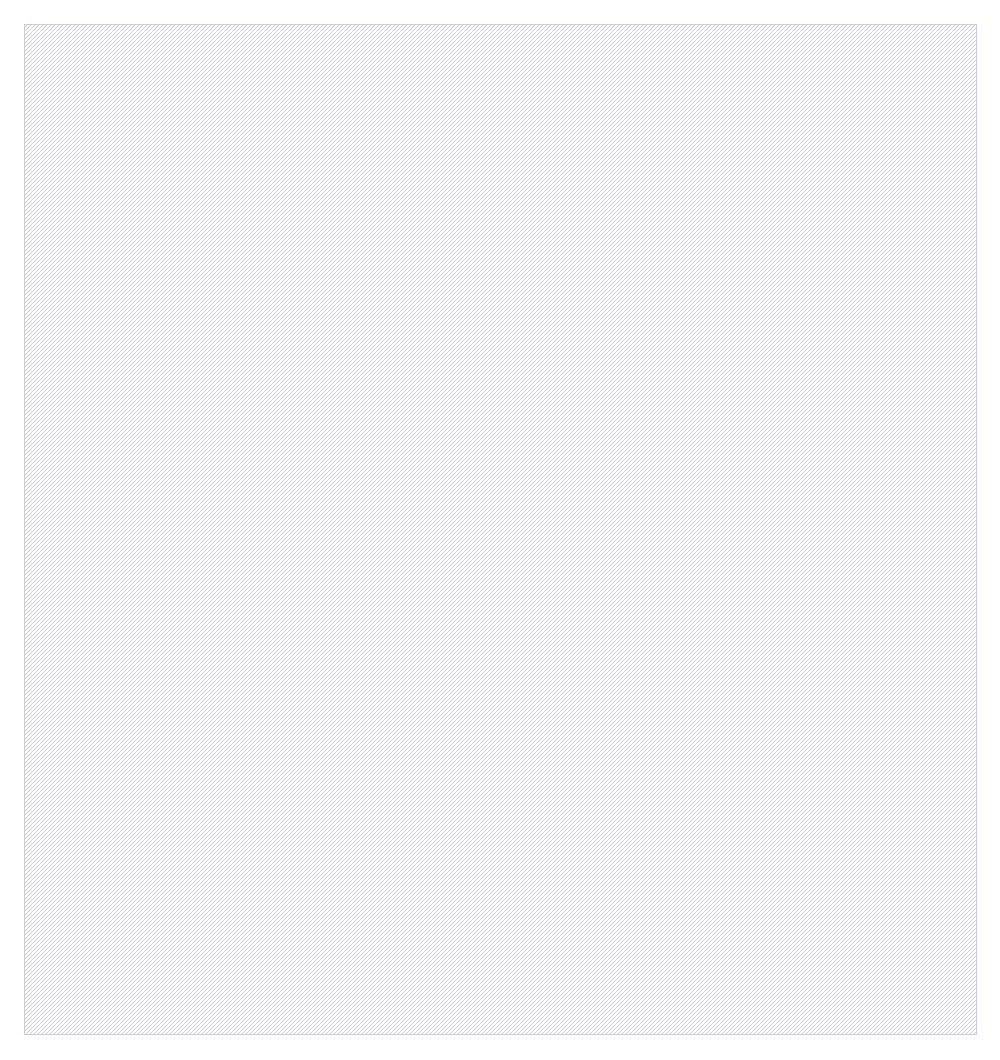

In [46]:
display(floorplan)

### Tap/Endcap Cell Insertion

This places two kinds of cells on the floorplan:

* End cap/boundary cells: Added at the beginning and end of each row. True to
  their name, they "cap off" the core area of a design.
* Tap cells: Placed in a polka dot-ish fashion across the rows. Tap cells
  connect VDD to the nwell and the psubstrate to VSS, which the majority of cells
  do not do themselves to save area- but if you go long enough without one such
  connection you end up with the cell "latching-up"; i.e.; refusing to switch
  back to LO from HI.

  There is a maximum distance between tap cells enforced as part of every
  foundry process.

In [47]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")

tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[18:39:35] VERBOSE  Running 'OpenROAD.TapEndcapInsertion' at                                           ]8;id=810926;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=387703;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/8-openroad-tapendcapinsertion'…                                                 

[18:39:35] VERBOSE  Logging subprocess to                                                              ]8;id=369503;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=806920;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/8-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log'…                 

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/8-openroad-tapendcapinsertion/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/8-openroad-tapendcapinsertion/spm.pnl.v'…

Writing layout to '/content/librelane_run/8-openroad-tapendcapinsertion/spm.def'…

Writing timing constraints to '/content/librelane_run/8-openroad-tapendcapinsertion/spm.sdc'…

Format,Path
nl,librelane_run/8-openroad-tapendcapinsertion/spm.nl.v
odb,librelane_run/8-openroad-tapendcapinsertion/spm.odb
def,librelane_run/8-openroad-tapendcapinsertion/spm.def
sdc,librelane_run/8-openroad-tapendcapinsertion/spm.sdc
pnl,librelane_run/8-openroad-tapendcapinsertion/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:39:36] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_8palgl5r'…               ]8;id=252784;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=414412;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:36] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_8palgl5r/klayout-render.log'…  ]8;id=945037;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=677976;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.43s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
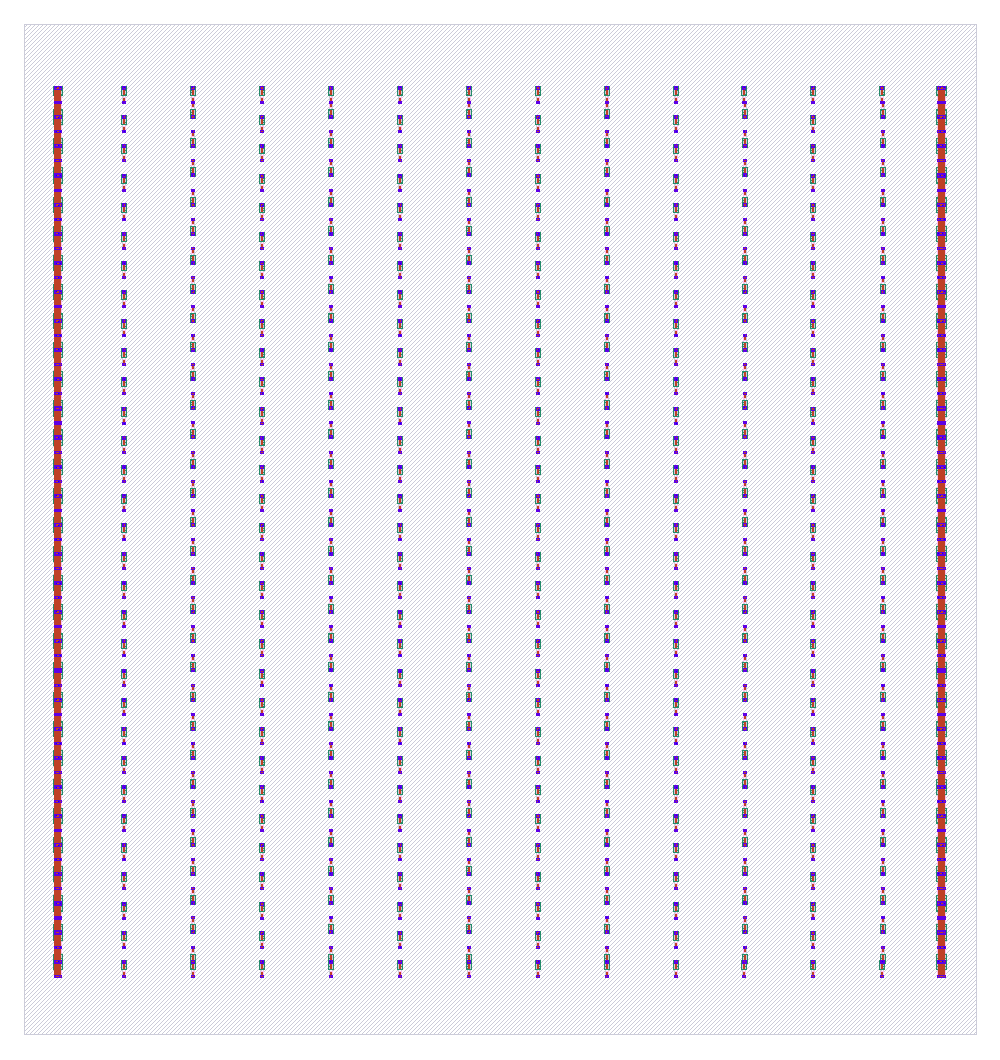

In [48]:
display(tdi)

### I/O Placement

This places metal pins at the edges of the design corresponding to the top level
inputs and outputs for your design. These pins act as the interface with other
designs when you integrate it with other designs.

In [49]:
IOPlacement = Step.factory.get("OpenROAD.IOPlacement")

ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()

────────────────────────────────────────────────── I/O Placement ──────────────────────────────────────────────────

[18:39:37] VERBOSE  Running 'OpenROAD.IOPlacement' at 'librelane_run/9-openroad-ioplacement'…          ]8;id=688925;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=225701;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:37] VERBOSE  Logging subprocess to                                                              ]8;id=732943;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=690089;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/9-openroad-ioplacement/openroad-ioplacement.log'…                               

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/9-openroad-ioplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/9-openroad-ioplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/9-openroad-ioplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/9-openroad-ioplacement/spm.sdc'…

Format,Path
nl,librelane_run/9-openroad-ioplacement/spm.nl.v
odb,librelane_run/9-openroad-ioplacement/spm.odb
def,librelane_run/9-openroad-ioplacement/spm.def
sdc,librelane_run/9-openroad-ioplacement/spm.sdc
pnl,librelane_run/9-openroad-ioplacement/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:39:39] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_5rf6q34n'…               ]8;id=117993;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=243925;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:39] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_5rf6q34n/klayout-render.log'…  ]8;id=120907;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=568860;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.54s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
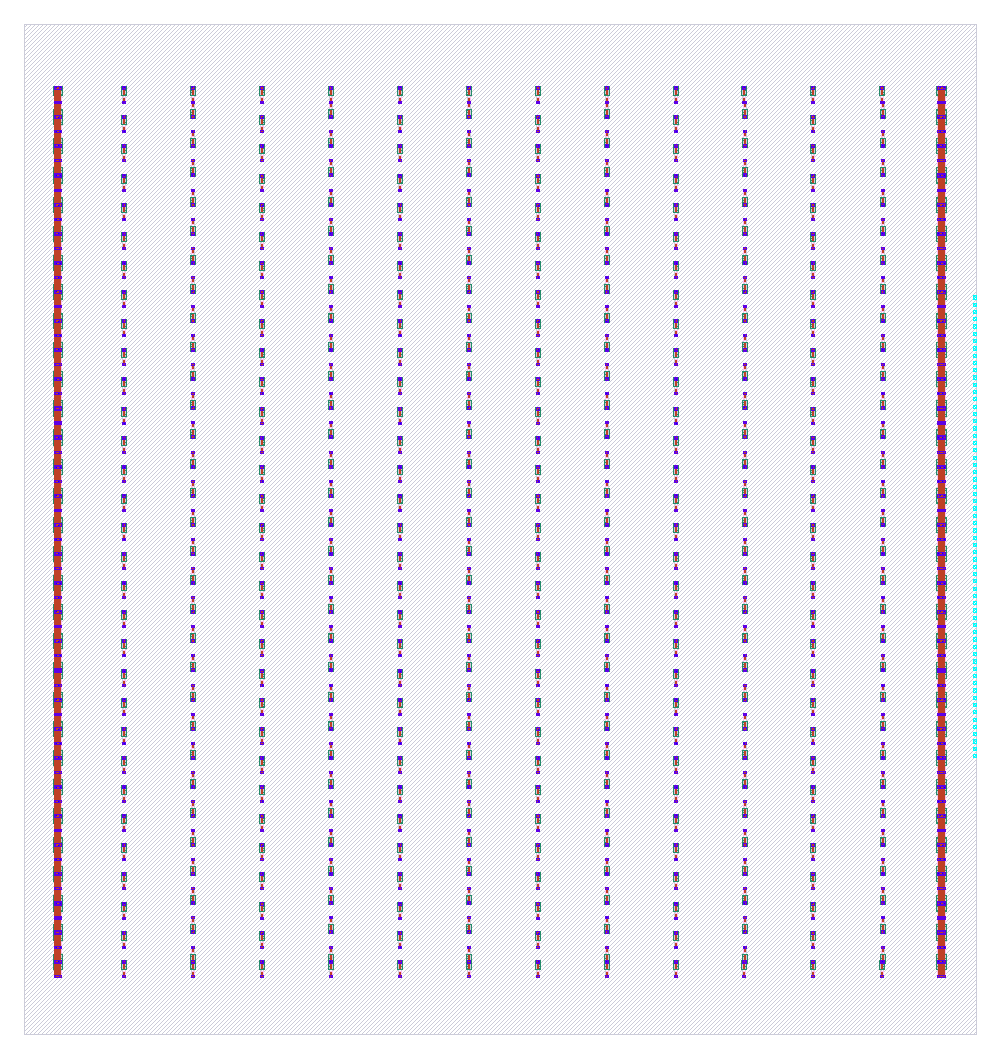

In [50]:
display(ioplace)

### Generating the Power Distribution Network (PDN)

This creates the power distribution network for your design, which is essentially
a plaid pattern of horizontal and vertical "straps" across the design that is
then connected to the rails' VDD and VSS (via the tap cells.)

You can find an explanation of how the power distribution network works at this
link: https://librelane.readthedocs.io/en/latest/usage/hardening_macros.html#pdn-generation

While we typically don't need to mess with the PDN too much, the SPM is a small
design, so we're going to need to make the plaid pattern formed by the PDN a bit
smaller.

In [51]:
GeneratePDN = Step.factory.get("OpenROAD.GeneratePDN")

pdn = GeneratePDN(
    state_in=ioplace.state_out,
    FP_PDN_VWIDTH=2,
    FP_PDN_HWIDTH=2,
    FP_PDN_VPITCH=30,
    FP_PDN_HPITCH=30,
)
pdn.start()

[18:39:40] INFO     Loading the incremental configuration has generated the following warnings:       ]8;id=324884;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=238697;file:///content/librelane_ipynb/librelane/config/config.py#333\333]8;;\

[18:39:40] WARNING  The configuration variable 'FP_PDN_VWIDTH' is deprecated. Please check the docs   ]8;id=887241;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=214472;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VWIDTH'.                                        

[18:39:40] WARNING  The configuration variable 'FP_PDN_HWIDTH' is deprecated. Please check the docs   ]8;id=446836;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=210252;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HWIDTH'.                                        

[18:39:40] WARNING  The configuration variable 'FP_PDN_VPITCH' is deprecated. Please check the docs   ]8;id=796460;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=670743;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VPITCH'.                                        

[18:39:40] WARNING  The configuration variable 'FP_PDN_HPITCH' is deprecated. Please check the docs   ]8;id=94864;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=977275;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HPITCH'.                                        

...

Writing layout to '/content/librelane_run/10-openroad-generatepdn/spm.def'…

Writing timing constraints to '/content/librelane_run/10-openroad-generatepdn/spm.sdc'…

[INFO PSM-0040] All shapes on net VPWR are connected.

[INFO PSM-0040] All shapes on net VGND are connected.

Format,Path
nl,librelane_run/10-openroad-generatepdn/spm.nl.v
odb,librelane_run/10-openroad-generatepdn/spm.odb
def,librelane_run/10-openroad-generatepdn/spm.def
sdc,librelane_run/10-openroad-generatepdn/spm.sdc
pnl,librelane_run/10-openroad-generatepdn/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:39:41] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_ipmxnkds'…               ]8;id=459511;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=640733;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:41] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_ipmxnkds/klayout-render.log'…  ]8;id=718414;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=836050;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.74s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
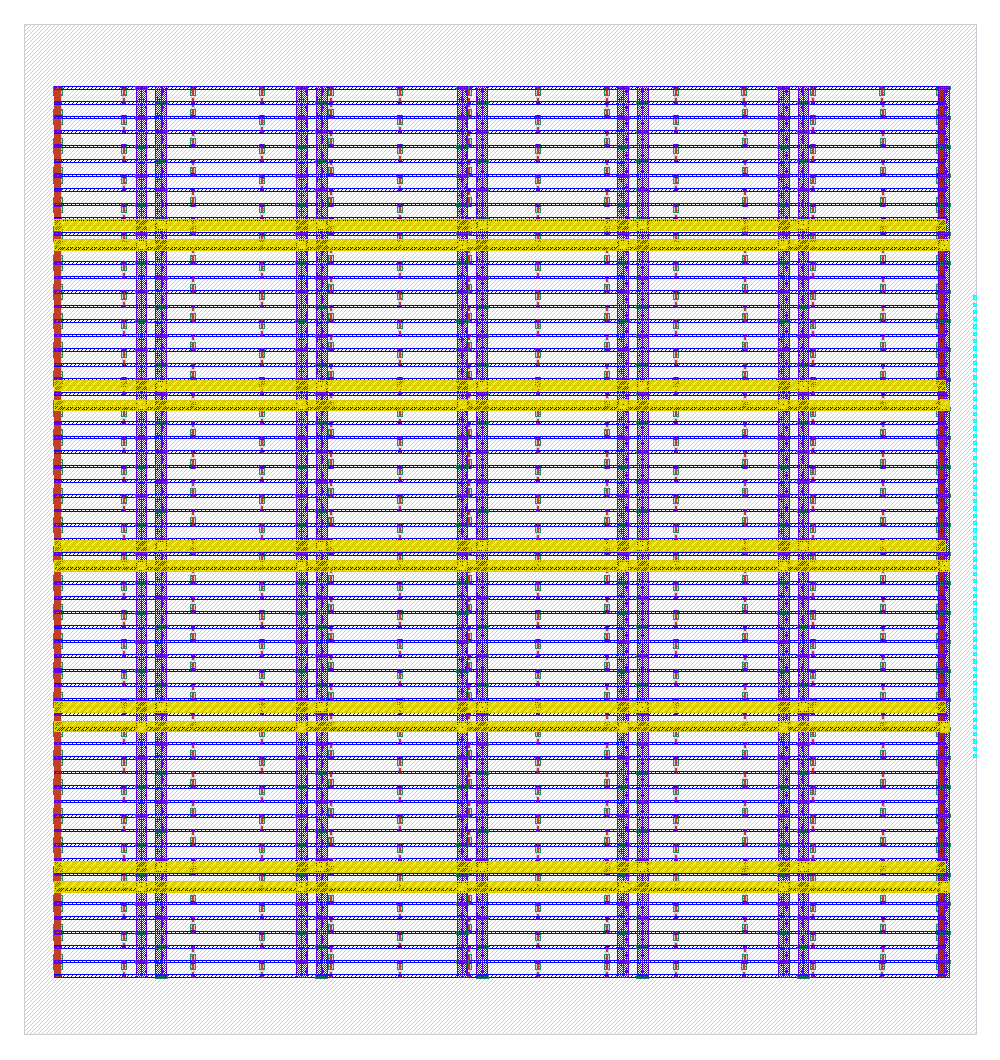

In [52]:
display(pdn)

### Global Placement

Global Placement is deciding on a fuzzy, non-final location for each of the cells,
with the aim of minimizing the distance between cells that are connected
together (more specifically, the total length of the not-yet-created wires that
will connect them).

As you will see in the `.display()` in the second cell below, the placement is
considered "illegal", i.e., not properly aligned with the cell placement grid.
This is addressed by "Detailed Placement", also referred to as "placement
legalization", which is the next step.

In [53]:
GlobalPlacement = Step.factory.get("OpenROAD.GlobalPlacement")

gpl = GlobalPlacement(state_in=pdn.state_out)
gpl.start()

──────────────────────────────────────────────── Global Placement ─────────────────────────────────────────────────

[18:39:42] VERBOSE  Running 'OpenROAD.GlobalPlacement' at 'librelane_run/11-openroad-globalplacement'… ]8;id=393550;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=480817;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:42] INFO     'PL_TARGET_DENSITY_PCT' not explicitly set, using dynamically calculated       ]8;id=104441;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=983353;file:///content/librelane_ipynb/librelane/steps/openroad.py#1581\1581]8;;\
                    target density: 62.092200…                                                                     

[18:39:42] VERBOSE  Logging subprocess to                                                              ]8;id=158023;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=406639;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/11-openroad-globalplacement/openroad-globalplacement.log'…                      

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/11-openroad-globalplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/11-openroad-globalplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/11-openroad-globalplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/11-openroad-globalplacement/spm.sdc'…

Format,Path
nl,librelane_run/11-openroad-globalplacement/spm.nl.v
odb,librelane_run/11-openroad-globalplacement/spm.odb
def,librelane_run/11-openroad-globalplacement/spm.def
sdc,librelane_run/11-openroad-globalplacement/spm.sdc
pnl,librelane_run/11-openroad-globalplacement/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:39:46] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_l3ydbbjr'…               ]8;id=8493;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=406387;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:46] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_l3ydbbjr/klayout-render.log'…  ]8;id=854564;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=286039;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 3.99s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
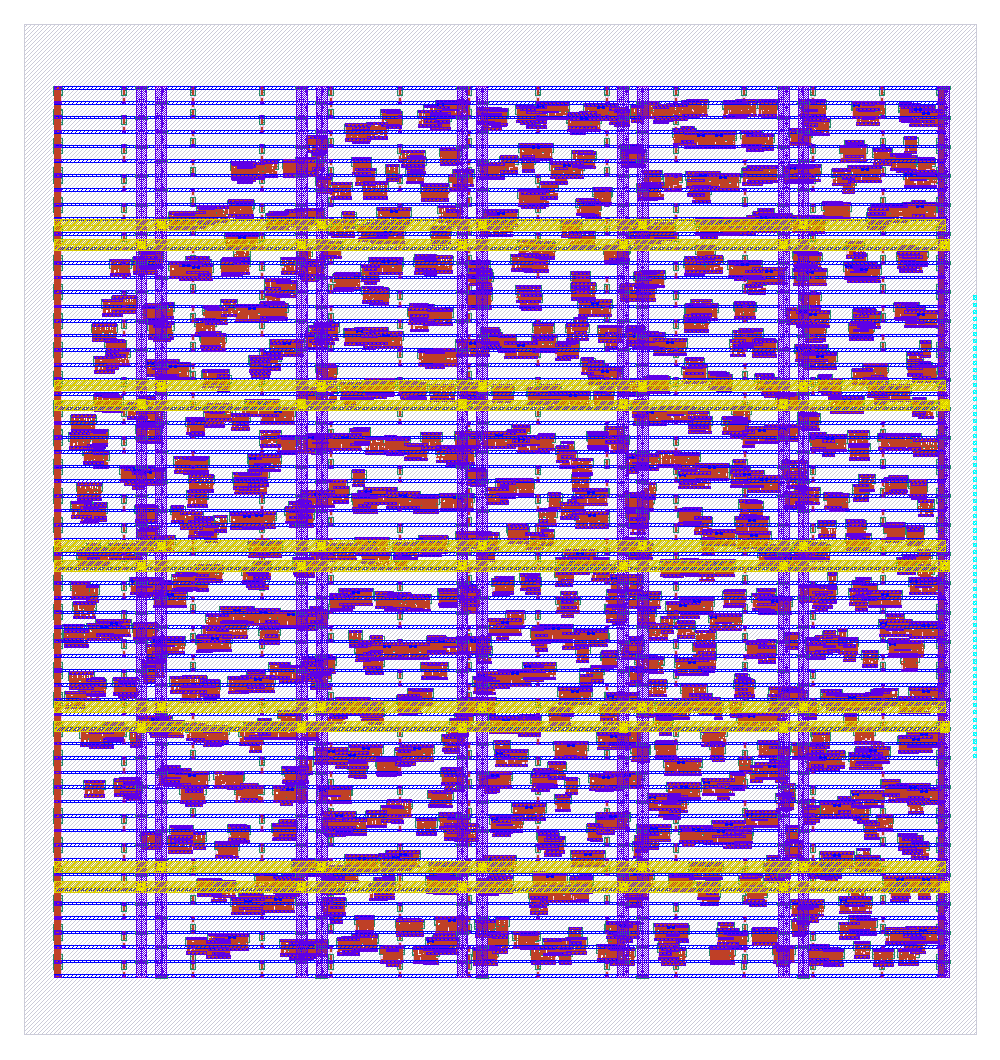

In [54]:
display(gpl)

### Detailed Placement

This aligns the fuzzy placement from before with the grid, "legalizing" it.

In [55]:
DetailedPlacement = Step.factory.get("OpenROAD.DetailedPlacement")

dpl = DetailedPlacement(state_in=gpl.state_out)
dpl.start()

─────────────────────────────────────────────── Detailed Placement ────────────────────────────────────────────────

[18:39:47] VERBOSE  Running 'OpenROAD.DetailedPlacement' at                                            ]8;id=633912;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=219670;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/12-openroad-detailedplacement'…                                                 

[18:39:47] VERBOSE  Logging subprocess to                                                              ]8;id=982487;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=225826;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/12-openroad-detailedplacement/openroad-detailedplacement.log'…                  

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/12-openroad-detailedplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/12-openroad-detailedplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/12-openroad-detailedplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/12-openroad-detailedplacement/spm.sdc'…

Format,Path
nl,librelane_run/12-openroad-detailedplacement/spm.nl.v
odb,librelane_run/12-openroad-detailedplacement/spm.odb
def,librelane_run/12-openroad-detailedplacement/spm.def
sdc,librelane_run/12-openroad-detailedplacement/spm.sdc
pnl,librelane_run/12-openroad-detailedplacement/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:39:49] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_03xz0gi7'…               ]8;id=390423;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=968354;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:49] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_03xz0gi7/klayout-render.log'…  ]8;id=955935;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=385575;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.84s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
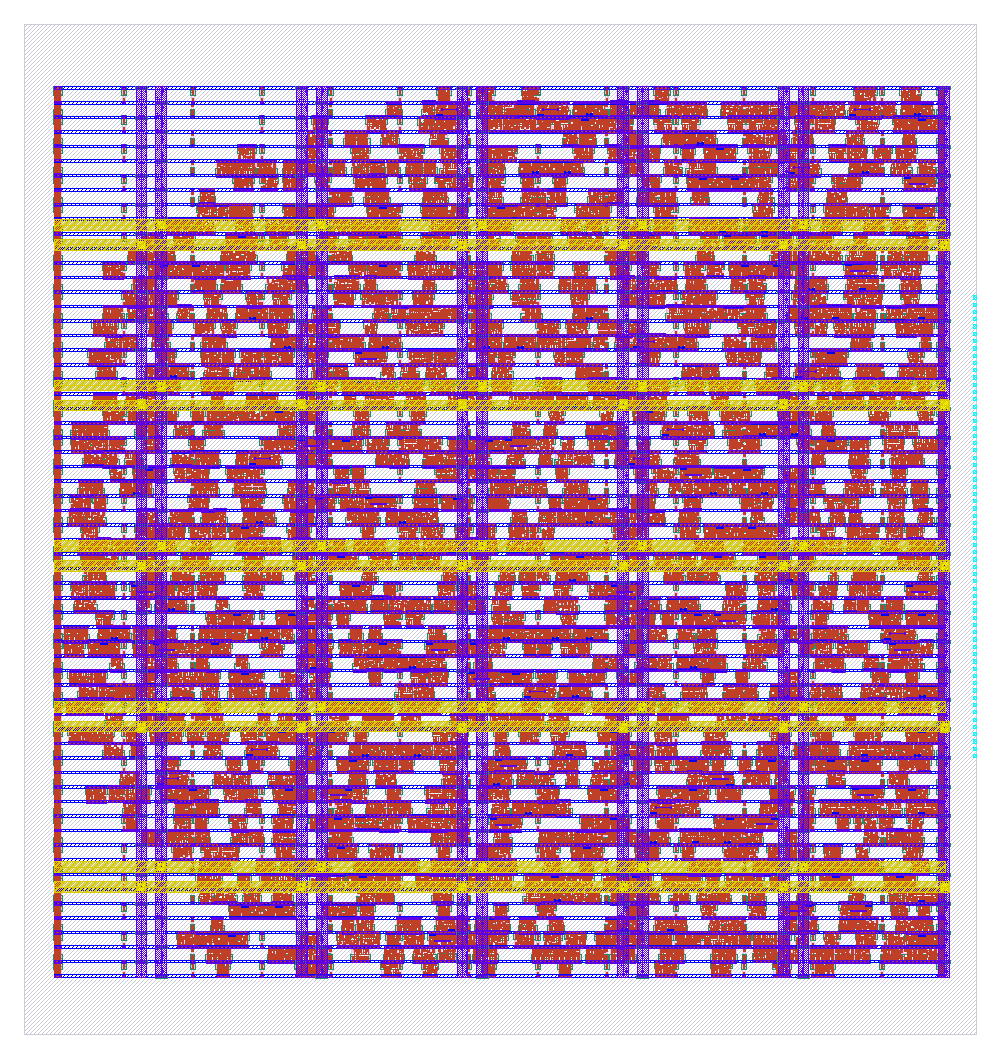

In [56]:
display(dpl)

### Clock Tree Synthesis (CTS)

With the cells now having a final placement, we can go ahead and create what
is known as the clock tree, i.e., the hierarchical set of buffers used
for clock signal to minimize what is known as "clock skew"- variable delay
of the clock cycle from register to register because of factors such as metal
wire length, clock load (number of gates connected to the same clock buffer,)
et cetera.

The CTS step creates the cells and places the between the gaps in the detailed
placement above.

In [57]:
CTS = Step.factory.get("OpenROAD.CTS")

cts = CTS(state_in=dpl.state_out)
cts.start()

────────────────────────────────────────────── Clock Tree Synthesis ───────────────────────────────────────────────

[18:39:50] VERBOSE  Running 'OpenROAD.CTS' at 'librelane_run/13-openroad-cts'…                         ]8;id=100544;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=863592;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:39:50] VERBOSE  Logging subprocess to 'librelane_run/13-openroad-cts/openroad-cts.log'…            ]8;id=29230;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=557832;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner max_tt_025C_1v80…

Reading timing library for the 'max_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/13-openroad-cts/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/13-openroad-cts/spm.pnl.v'…

Writing layout to '/content/librelane_run/13-openroad-cts/spm.def'…

Writing timing constraints to '/content/librelane_run/13-openroad-cts/spm.sdc'…

Format,Path
nl,librelane_run/13-openroad-cts/spm.nl.v
odb,librelane_run/13-openroad-cts/spm.odb
def,librelane_run/13-openroad-cts/spm.def
sdc,librelane_run/13-openroad-cts/spm.sdc
pnl,librelane_run/13-openroad-cts/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:40:20] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_vkkha1yx'…               ]8;id=517211;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=953962;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:40:20] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_vkkha1yx/klayout-render.log'…  ]8;id=757567;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=596385;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 29.28s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
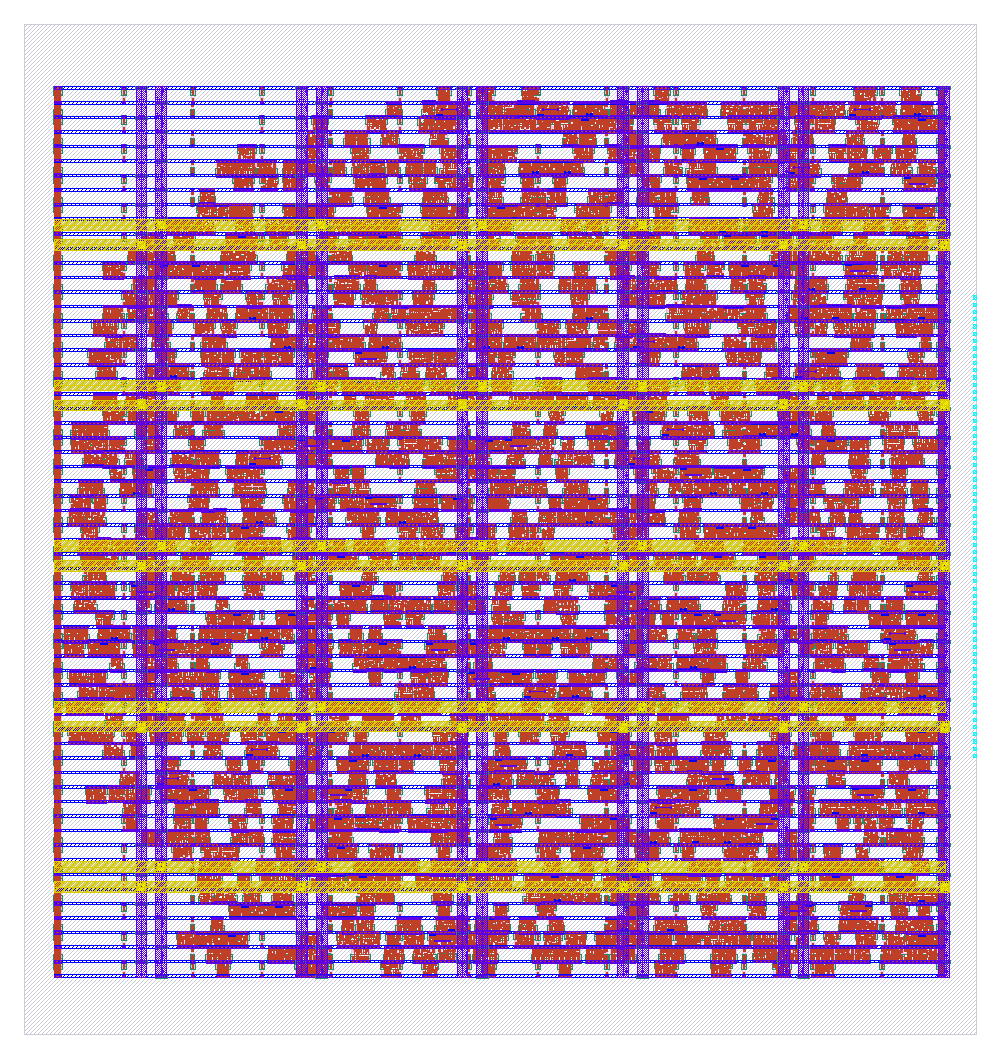

In [58]:
display(cts)

### Global Routing

Global routing "plans" the routes the wires between two gates (or gates and
I/O pins/the PDN) will take. The results of global routing (which are called
"routing guides") are stored in internal data structures and have no effect on
the actual design, so there is no `display()` statement.

In [59]:
GlobalRouting = Step.factory.get("OpenROAD.GlobalRouting")

grt = GlobalRouting(state_in=cts.state_out)
grt.start()

───────────────────────────────────────────────── Global Routing ──────────────────────────────────────────────────

[18:40:21] VERBOSE  Running 'OpenROAD.GlobalRouting' at 'librelane_run/14-openroad-globalrouting'…     ]8;id=817148;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=596849;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:40:21] VERBOSE  Logging subprocess to                                                              ]8;id=50978;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=749081;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/14-openroad-globalrouting/openroad-globalrouting.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Multi-Input combinational cell         1395   13873.31

Total                                  1907   14850.49

Writing OpenROAD database to '/content/librelane_run/14-openroad-globalrouting/spm.odb'…

Writing layout to '/content/librelane_run/14-openroad-globalrouting/spm.def'…

Format,Path
nl,librelane_run/13-openroad-cts/spm.nl.v
odb,librelane_run/14-openroad-globalrouting/spm.odb
def,librelane_run/14-openroad-globalrouting/spm.def
sdc,librelane_run/13-openroad-cts/spm.sdc
pnl,librelane_run/13-openroad-cts/spm.pnl.v


### Detailed Routing

Detailed routing uses the guides from Global Routing to actually create wires
on the metal layers and connect the gates, making the connections finally physical.

This is typically the longest step in the flow.

In [60]:
DetailedRouting = Step.factory.get("OpenROAD.DetailedRouting")

drt = DetailedRouting(state_in=grt.state_out)
drt.start()

──────────────────────────────────────────────── Detailed Routing ─────────────────────────────────────────────────

[18:40:23] VERBOSE  Running 'OpenROAD.DetailedRouting' at 'librelane_run/15-openroad-detailedrouting'… ]8;id=56106;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=842775;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:40:23] INFO     Running TritonRoute with 2 threads…                                            ]8;id=70969;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=839827;file:///content/librelane_ipynb/librelane/steps/openroad.py#2002\2002]8;;\

[18:40:23] VERBOSE  Logging subprocess to                                                              ]8;id=615044;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=738632;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/15-openroad-detailedrouting/openroad-detailedrouting.log'…                      

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/15-openroad-detailedrouting/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/15-openroad-detailedrouting/spm.pnl.v'…

Writing layout to '/content/librelane_run/15-openroad-detailedrouting/spm.def'…

Writing timing constraints to '/content/librelane_run/15-openroad-detailedrouting/spm.sdc'…

Format,Path
nl,librelane_run/15-openroad-detailedrouting/spm.nl.v
odb,librelane_run/15-openroad-detailedrouting/spm.odb
def,librelane_run/15-openroad-detailedrouting/spm.def
sdc,librelane_run/15-openroad-detailedrouting/spm.sdc
pnl,librelane_run/15-openroad-detailedrouting/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:44:13] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_w1kk9c_1'…               ]8;id=204162;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=142219;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:13] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_w1kk9c_1/klayout-render.log'…  ]8;id=418087;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=32631;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 229.07s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
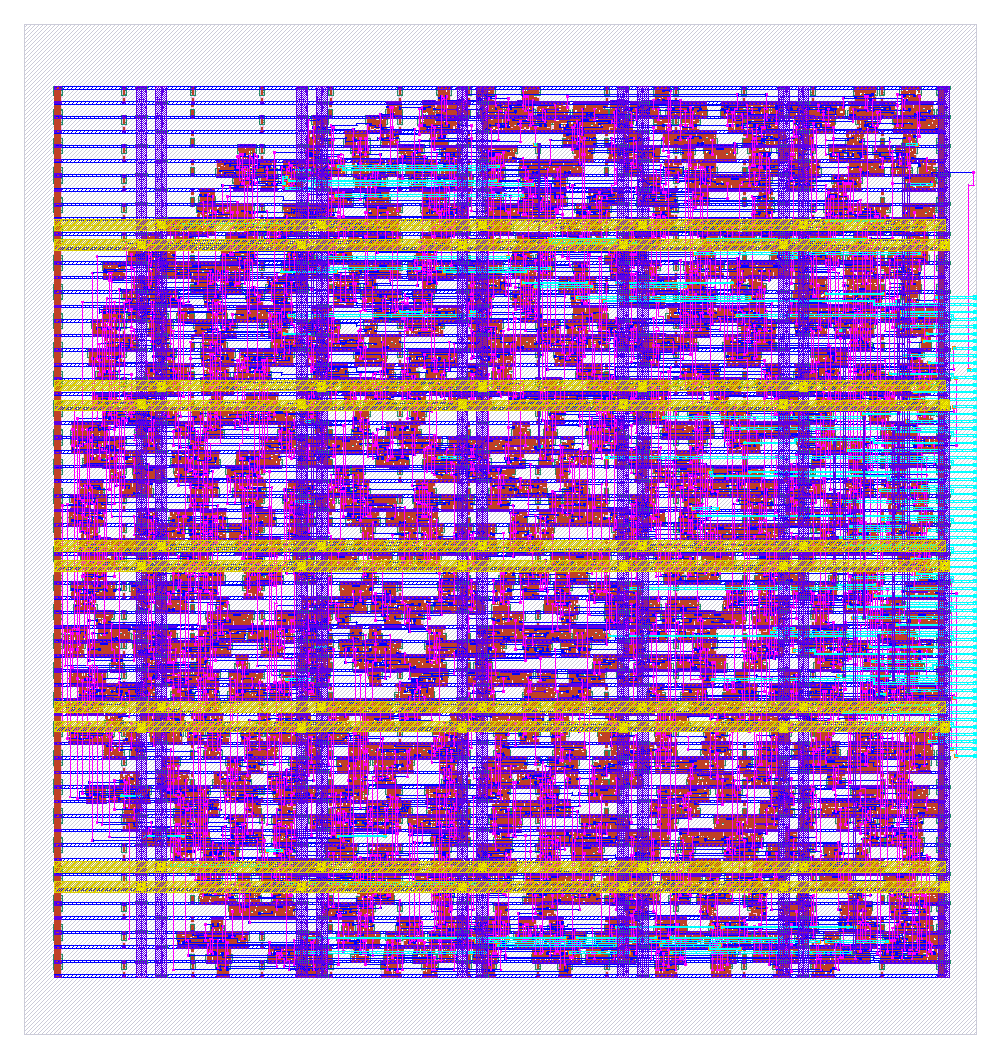

In [61]:
display(drt)

### Fill Insertion

Finally, as we're done placing all the essential cells, the only thing left to
do is fill in the gaps.

We prioritize the use of decap (decoupling capacitor) cells, which
further supports the power distribution network, but when there aren't any
small enough cells, we just use regular fill cells.

In [62]:
FillInsertion = Step.factory.get("OpenROAD.FillInsertion")

fill = FillInsertion(state_in=drt.state_out)
fill.start()

───────────────────────────────────────────────── Fill Insertion ──────────────────────────────────────────────────

[18:44:14] VERBOSE  Running 'OpenROAD.FillInsertion' at 'librelane_run/16-openroad-fillinsertion'…     ]8;id=523575;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=431583;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:14] VERBOSE  Logging subprocess to                                                              ]8;id=965402;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=489662;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/16-openroad-fillinsertion/openroad-fillinsertion.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/16-openroad-fillinsertion/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/16-openroad-fillinsertion/spm.pnl.v'…

Writing layout to '/content/librelane_run/16-openroad-fillinsertion/spm.def'…

Writing timing constraints to '/content/librelane_run/16-openroad-fillinsertion/spm.sdc'…

Format,Path
nl,librelane_run/16-openroad-fillinsertion/spm.nl.v
odb,librelane_run/16-openroad-fillinsertion/spm.odb
def,librelane_run/16-openroad-fillinsertion/spm.def
sdc,librelane_run/16-openroad-fillinsertion/spm.sdc
pnl,librelane_run/16-openroad-fillinsertion/spm.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:44:16] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_8p8dnlil'…               ]8;id=421025;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=440556;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:16] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_8p8dnlil/klayout-render.log'…  ]8;id=555278;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=956438;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.74s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
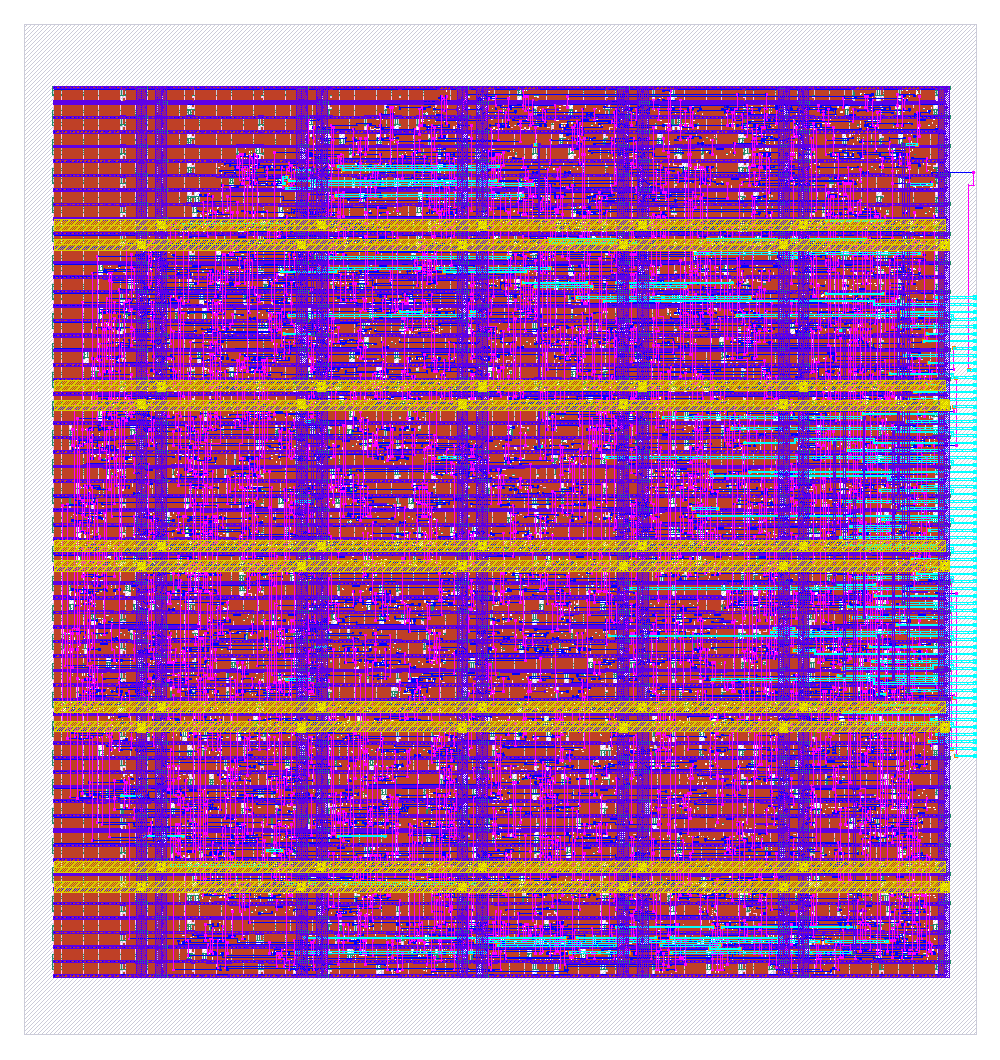

In [63]:
display(fill)

### Parasitics Extraction a.k.a. Resistance/Capacitance Extraction (RCX)

This step does not alter the design- rather, it computes the
[Parasitic elements](https://en.wikipedia.org/wiki/Parasitic_element_(electrical_networks))
of the circuit, which have an effect of timing, as we prepare to do the final
timing analysis.

The parasitic elements are saved in the **Standard Parasitics Exchange Format**,
or SPEF. LibreLane creates a SPEF file for each interconnect corner as described in
the [Corners and STA](https://librelane.readthedocs.io/en/latest/usage/corners_and_sta.html)
section of the documentation.

In [64]:
RCX = Step.factory.get("OpenROAD.RCX")

rcx = RCX(state_in=fill.state_out)
rcx.start()

─────────────────────────────────── Parasitic Resistance/Capacitance Extraction ───────────────────────────────────

[18:44:17] VERBOSE  Running 'OpenROAD.RCX' at 'librelane_run/17-openroad-rcx'…                         ]8;id=681537;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=161321;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:17] INFO     Running RCX for corners matching nom_*                                         ]8;id=957829;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=390947;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/17-openroad-rcx/nom/rcx.log)…                                          

[18:44:17] INFO     Running RCX for corners matching min_*                                         ]8;id=872947;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=441746;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/17-openroad-rcx/min/rcx.log)…                                          

[18:44:17] VERBOSE  Logging subprocess to 'librelane_run/17-openroad-rcx/min/rcx.log'…                 ]8;id=860201;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=913344;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

...

[18:44:19] INFO     Running RCX for corners matching max_*                                         ]8;id=725261;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=953482;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/17-openroad-rcx/max/rcx.log)…                                          

[18:44:19] VERBOSE  Logging subprocess to 'librelane_run/17-openroad-rcx/max/rcx.log'…                 ]8;id=972821;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=633816;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[18:44:19] INFO     Finished RCX for corners matching nom_*.                                       ]8;id=186979;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=808210;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

[18:44:20] INFO     Finished RCX for corners matching max_*.                                       ]8;id=249642;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=28852;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

{'nl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/16-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/16-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/16-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/17-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/17-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/17-openroad-rcx/max/spm.max.spef')}, 'metrics': {'design__instance__count': 5739, 'design__instance__area': 27629, 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 177.89 188.61', 'design__core__bbox': '5.52 10.88 172.04 176.8', 'design__io': 66, 'design__die__area': Decimal('33551.8'), 'design__core__area': 27629, 'design__instance__count__stdcell': 1785, 'design__instance__area__stdcell': Decimal('14392.6'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.520922'), 'design__instance__utilization__stdcell': Decimal('0.520922'), 'design__rows': 61, 'design__rows:unithd': 61, 'design__sites': 22082, 'design__sites:unithd': 22082, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('5.0048'), 'design__instance__count__class:inverter': 11, 'design__instance__area__class:inverter': Decimal('41.2896'), 'design__instance__count__class:multi_input_combinational_cell': 1395, 'design__instance__area__class:multi_input_combinational_cell': Decimal('13873.3'), 'flow__warnings__count': 4, 'flow__errors__count': 0, 'flow__warnings__count:ODB-0220': 2, 'flow__warnings__count:STA-0366': 2, 'flow__warnings__count:STA-0419': 1, 'flow__warnings__count:STA-0450': 1, 'flow__warnings__type_count': 3, 'design__instance__count__class:fill_cell': 3954, 'design__instance__area__class:fill_cell': Decimal('13236.4'), 'design__instance__count__class:tap_cell': 378, 'design__instance__area__class:tap_cell': Decimal('472.954'), 'floorplan__design__io': 64, 'design__io__hpwl': 7085120, 'design__power_grid_violation__count__net:VGND': 0, 'design__power_grid_violation__count__net:VPWR': 0, 'design__power_grid_violation__count': 0, 'design__instance__displacement__total': 0, 'design__instance__displacement__mean': 0, 'design__instance__displacement__max': 0, 'route__wirelength__estimated': 27726, 'design__violations': 0, 'flow__warnings__count:CTS-0082': 1, 'flow__warnings__count:CTS-0083': 1, 'flow__warnings__count:STA-1140': 6, 'global_route__vias': 10155, 'global_route__wirelength': 57173, 'route__net': 1439, 'route__net__special': 2, 'route__drc_errors__iter:0': 589, 'route__wirelength__iter:0': 36501, 'route__drc_errors__iter:1': 254, 'route__wirelength__iter:1': 36192, 'route__drc_errors__iter:2': 170, 'route__wirelength__iter:2': 36105, 'route__drc_errors__iter:3': 1, 'route__wirelength__iter:3': 36084, 'route__drc_errors__iter:4': 0, 'route__wirelength__iter:4': 36080, 'route__drc_errors': 0, 'route__wirelength': 36080, 'route__vias': 11125, 'route__vias__singlecut': 11125, 'route__vias__multicut': 0, 'antenna__violating__nets': 0, 'antenna__violating__pins': 0, 'flow__warnings__count:DRT-0349': 10}}

### Static Timing Analysis (Post-PnR)

STA is a process that verifies that a chip meets certain constraints on clock
and data timings to run at its rated clock speed. See [Corners and STA](https://librelane.readthedocs.io/en/latest/usage/corners_and_sta.html)
in the documentation for more info.

---

This step generates two kinds of files:
* `.lib`: Liberty™-compatible Library files. Can be used to do static timing
  analysis when creating a design with this design as a sub-macro.
* `.sdf`: Standard Delay Format. Can be used with certain simulation software
  to do *dynamic* timing analysis.

Unfortunately, the `.lib` files coming out of LibreLane right now are not super
reliable for timing purposes and are only provided for completeness.

When using LibreLane-created macros withing other designs, it is best to use the
macro's final netlist and extracted parasitics instead.

In [65]:
STAPostPNR = Step.factory.get("OpenROAD.STAPostPNR")

sta_post_pnr = STAPostPNR(state_in=rcx.state_out)
sta_post_pnr.start()

──────────────────────────────────────── Static Timing Analysis (Post-PnR) ────────────────────────────────────────

[18:44:20] VERBOSE  Running 'OpenROAD.STAPostPNR' at 'librelane_run/18-openroad-stapostpnr'…           ]8;id=494058;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=123813;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:20] INFO     Starting STA for the nom_tt_025C_1v80 timing corner…                            ]8;id=900042;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=518313;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[18:44:20] INFO     Starting STA for the nom_ss_100C_1v60 timing corner…                            ]8;id=57191;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=954311;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[18:44:20] VERBOSE  Logging subprocess to                                                              ]8;id=942769;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=864003;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/sta.log'…                               

...

[18:44:48] INFO     Finished STA for the max_ff_n40C_1v95 timing corner.                            ]8;id=840594;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=384463;file:///content/librelane_ipynb/librelane/steps/openroad.py#762\762]8;;\

[18:44:48] VERBOSE  Logging subprocess to                                                              ]8;id=447599;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=71775;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log'…                

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┓
┃                      ┃       ┃       ┃      ┃       ┃ of   ┃       ┃      ┃       ┃      ┃ of    ┃      ┃       ┃
┃                      ┃       ┃ Reg   ┃      ┃       ┃ whi… ┃       ┃ Reg  ┃       ┃      ┃ which ┃      ┃       ┃
┃                      ┃ Hold  ┃ to    ┃      ┃ Hold  ┃ reg  ┃ Setup ┃ to   ┃       ┃ Set… ┃ reg   ┃ Max  ┃ Max   ┃
┃                      ┃ Worst ┃ Reg   ┃ Hold ┃ Vio   ┃ to   ┃ Worst ┃ Reg  ┃ Setup ┃ Vio  ┃ to    ┃ Cap  ┃ Slew  ┃
┃ Corner/Group         ┃ Slack ┃ Paths ┃ TNS  ┃ Count ┃ reg  ┃ Slack ┃ Pat… ┃ TNS   ┃ Cou… ┃ reg   ┃ Vio… ┃ Viol… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━┩
│ Overall              │ 4.10… │ N/A   │ 0.0… │ 0     │ 0    │ -9.5… │ N/A  │ -148… │ 125  │ 0     │ 10   │ 1008  │
│ nom_tt_025C_1v80     │ 4.34… │ N/A   │ 0.0… │ 0     │ 0    │ -1.3… │ N/A  │ -10.… │ 14   │ 0     │ 4    │ 699   │
│ nom_ss_100C_1v60     │ 4.87… │ N/A   │ 0.0… │ 0     │ 0    │ -9.3… │ N/A  │ -145… │ 28   │ 0     │ 4    │ 1008  │
│ nom_ff_n40C_1v95     │ 4.11… │ N/A   │ 0.0… │ 0     │ 0    │ 1.44… │ N/A  │ 0.00… │ 0    │ 0     │ 5    │ 0     │
│ min_tt_025C_1v80     │ 4.32… │ N/A   │ 0.0… │ 0     │ 0    │ -1.3… │ N/A  │ -9.0… │ 13   │ 0     │ 0    │ 518   │
│ min_ss_100C_1v60     │ 4.84… │ N/A   │ 0.0… │ 0     │ 0    │ -9.2… │ N/A  │ -141… │ 28   │ 0     │ 0    │ 1004  │
│ min_ff_n40C_1v95     │ 4.10… │ N/A   │ 0.0… │ 0     │ 0    │ 1.50… │ N/A  │ 0.00… │ 0    │ 0     │ 0    │ 0     │
│ max_tt_025C_1v80     │ 4.36… │ N/A   │ 0.0… │ 0     │ 0    │ -1.4… │ N/A  │ -11.… │ 14   │ 0     │ 10   │ 853   │
│ max_ss_100C_1v60     │ 4.91… │ N/A   │ 0.0… │ 0     │ 0    │ -9.5… │ N/A  │ -148… │ 28   │ 0     │ 10   │ 1008  │
│ max_ff_n40C_1v95     │ 4.12… │ N/A   │ 0.0… │ 0     │ 0    │ 1.38… │ N/A  │ 0.00… │ 0    │ 0     │ 10   │ 0     │
└──────────────────────┴───────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┘

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃                      ┃ Hold     ┃ Reg to   ┃          ┃          ┃ of which  ┃ Setup    ┃           ┃          ┃           ┃ of which ┃           ┃          ┃
┃                      ┃ Worst    ┃ Reg      ┃          ┃ Hold Vio ┃ reg to    ┃ Worst    ┃ Reg to    ┃ Setup    ┃ Setup Vio ┃ reg to   ┃ Max Cap   ┃ Max Slew ┃
┃ Corner/Group         ┃ Slack    ┃ Paths    ┃ Hold TNS ┃ Count    ┃ reg       ┃ Slack    ┃ Reg Paths ┃ TNS      ┃ Count     ┃ reg      ┃ Violatio… ┃ Violati… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ Overall              │ 4.1028   │ N/A      │ 0.0000   │ 0        │ 0         │ -9.5304  │ N/A       │ -148.63… │ 125       │ 0        │ 10        │ 1008     │
│ nom_tt_025C_1v80     │ 4.3479   │ N/A      │ 0.0000   │ 0        │ 0         │ -1.3905  │ N/A       │ -10.1033 │ 14        │ 0        │ 4         │ 699      │
│ nom_ss_100C_1v60     │ 4.8765   │ N/A      │ 0.0000   │ 0        │ 0         │ -9.3937  │ N/A       │ -145.17… │ 28        │ 0        │ 4         │ 1008     │
│ nom_ff_n40C_1v95     │ 4.1164   │ N/A      │ 0.0000   │ 0        │ 0         │ 1.4457   │ N/A       │ 0.0000   │ 0         │ 0        │ 5         │ 0        │
│ min_tt_025C_1v80     │ 4.3282   │ N/A      │ 0.0000   │ 0        │ 0         │ -1.3066  │ N/A       │ -9.0521  │ 13        │ 0        │ 0         │ 518      │
│ min_ss_100C_1v60     │ 4.8400   │ N/A      │ 0.0000   │ 0        │ 0         │ -9.2697  │ N/A       │ -141.67… │ 28        │ 0        │ 0         │ 1004     │
│ min_ff_n40C_1v95     │ 4.1028   │ N/A      │ 0.0000   │ 0        │ 0         │ 1.5050   │ N/A       │ 0.0000   │ 0         │ 0        │ 0         │ 0        │
│ max_tt_025C_1v80     │ 4.3669   │ N/A      │ 0.0000   │ 0        │ 0         │ -1.4844  │ N/A       │ -11.2588 │ 14        │ 0        │ 10        │ 853      │
│ max_ss_100C_1v60     │ 4.9101   │ N/A      │ 0.0000   │ 0        │ 0         │ -9.5304  │ N/A       │ -148.63… │ 28        │ 0        │ 10        │ 1008     │
│ max_ff_n40C_1v95     │ 4.1294   │ N/A      │ 0.0000   │ 0        │ 0         │ 1.3811   │ N/A       │ 0.0000   │ 0         │ 0        │ 10        │ 0        │
└──────────────────────┴──────────┴──────────┴──────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┘

{'nl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/16-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/16-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/16-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/17-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/17-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/17-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'metrics': {'design__instance__count': 5739, 'design__instance__area': 27629, 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 177.89 188.61', 'design__core__bbox': '5.52 10.88 172.04 176.8', 'design__io': 66, 'design__die__area': Decimal('33551.8'), 'design__core__area': 27629, 'design__instance__count__stdcell': 1785, 'design__instance__area__stdcell': Decimal('14392.6'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.520922'), 'design__instance__utilization__stdcell': Decimal('0.520922'), 'design__rows': 61, 'design__rows:unithd': 61, 'design__sites': 22082, 'design__sites:unithd': 22082, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('5.0048'), 'design__instance__count__class:inverter': 11, 'design__instance__area__class:inverter': Decimal('41.2896'), 'design__instance__count__class:multi_input_combinational_cell': 1395, 'design__instance__area__class:multi_input_combinational_cell': Decimal('13873.3'), 'flow__warni

### Stream-out

Stream-out is the process of converting the designs from the abstract formats
using during floorplanning, placement and routing into a concrete format called
GDSII (lit. Graphic Design System 2), which is the final file that is then sent
for fabrication.

In [66]:
StreamOut = Step.factory.get("KLayout.StreamOut")

gds = StreamOut(state_in=sta_post_pnr.state_out)
gds.start()

─────────────────────────────────────────── GDSII Stream Out (KLayout) ────────────────────────────────────────────

[18:44:49] VERBOSE  Running 'KLayout.StreamOut' at 'librelane_run/19-klayout-streamout'…               ]8;id=324977;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=56826;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:49] VERBOSE  Logging subprocess to 'librelane_run/19-klayout-streamout/klayout-streamout.log'…  ]8;id=634090;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=37052;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[INFO] Clearing cells…

[INFO] Merging GDS files…

...

[INFO] Checking for missing GDS…

[INFO] All LEF cells have matching GDS cells.

[INFO] Writing out GDS '/content/librelane_run/19-klayout-streamout/spm.klayout.gds'…

[INFO] Done.

{'nl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/16-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/16-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/16-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/17-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/17-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/17-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/19-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/19-klayout-streamout/spm.gds'), 'metrics': {'design__instance__count': 5739, 'design__instance__area': 27629, 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 177.89 188.61', 'design__core__bbox': '5.52 10.88 172.04 176.8', 'design__io': 66, 'design__die__area': Decimal('33551.8'), 'design__core__area': 27629, 'design__instance__count__stdcell': 1785, 'design__instance__area__stdcell': Decimal('14392.6'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.520922'), 'design__instance__utilization__stdcell': Decimal('0.520922'), 'design__rows': 61, 'design__rows:unithd': 61, 'design__sites': 22082, 'design__sites:unithd': 22082, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('5.0048'), 'design__instance__count__class:inverter': 11, 'design__instance__area__class:inverter': Decimal('41.2896'), 'design__instan

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[18:44:50] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp__6kafr1z'…               ]8;id=337186;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=740423;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:50] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp__6kafr1z/klayout-render.log'…  ]8;id=383659;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=204527;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 0.72s
#### Views updated:
* GDSII Stream (KLayout)
* GDSII Stream
#### Preview:
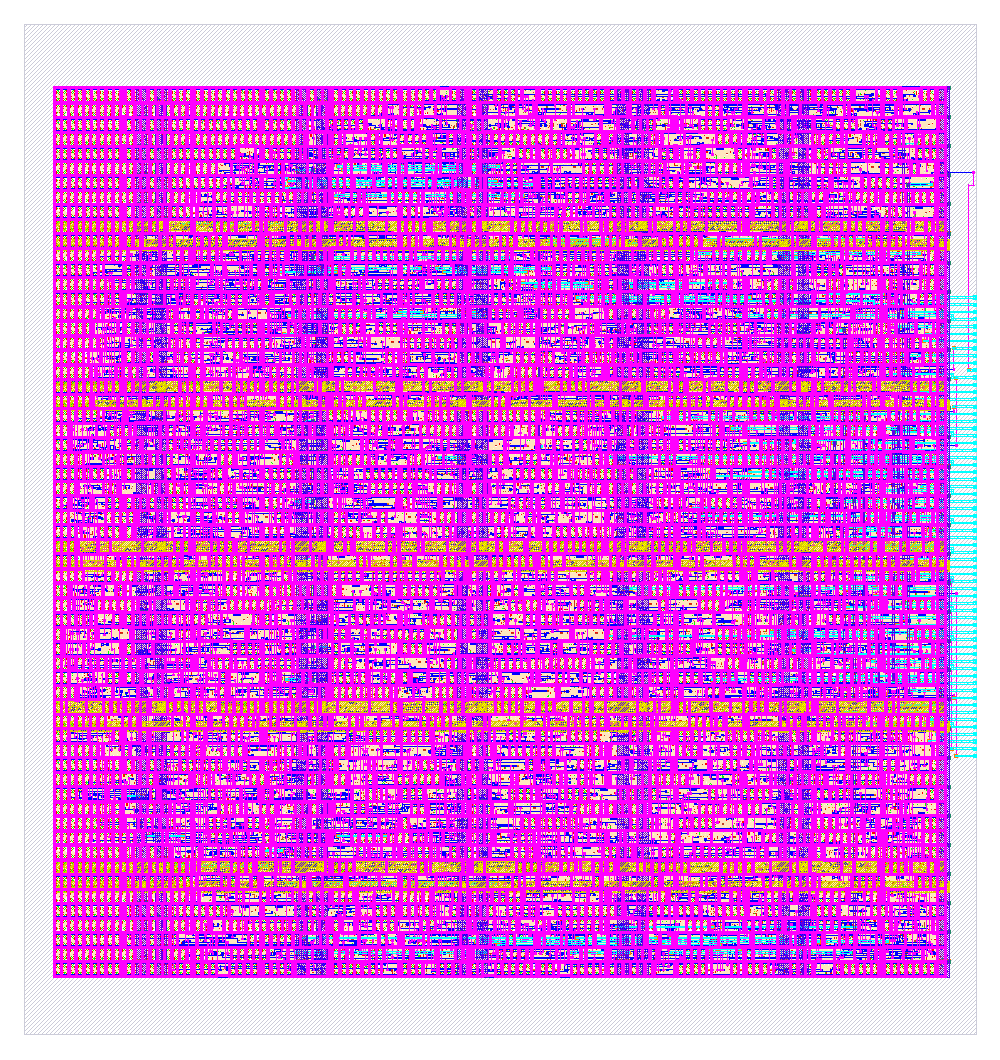

In [67]:
display(gds)

### Design Rule Checks (DRC)

DRC determines that the final layout does not violate any of the rules set by
the foundry to ensure the design is actually manufacturable- for example,
not enough space between two wires, *too much* space between tap cells, and so
on.

A design not passing DRC will typically be rejected by the foundry, who
also run DRC on their side.

In [68]:
DRC = Step.factory.get("Magic.DRC")

drc = DRC(state_in=gds.state_out)
drc.start()

─────────────────────────────────────────────── Design Rule Checks ────────────────────────────────────────────────

[18:44:51] VERBOSE  Running 'Magic.DRC' at 'librelane_run/20-magic-drc'…                               ]8;id=436785;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=687694;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:44:51] VERBOSE  Logging subprocess to 'librelane_run/20-magic-drc/magic-drc.log'…                  ]8;id=805125;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=834755;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

[INFO] Should be divided by 3 or 4

[INFO] DRC Checking DONE (/content/librelane_run/20-magic-drc/reports/drc.magic.rpt)

[INFO] Saving mag view with DRC errors (/content/librelane_run/20-magic-drc/views/spm.drc.mag)

[INFO] Saved

{'nl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/16-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/16-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/16-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/17-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/17-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/17-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/19-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/19-klayout-streamout/spm.gds'), 'metrics': {'design__instance__count': 5739, 'design__instance__area': 27629, 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 177.89 188.61', 'design__core__bbox': '5.52 10.88 172.04 176.8', 'design__io': 66, 'design__die__area': Decimal('33551.8'), 'design__core__area': 27629, 'design__instance__count__stdcell': 1785, 'design__instance__area__stdcell': Decimal('14392.6'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.520922'), 'design__instance__utilization__stdcell': Decimal('0.520922'), 'design__rows': 61, 'design__rows:unithd': 61, 'design__sites': 22082, 'design__sites:unithd': 22082, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('5.0048'), 'design__instance__count__class:inverter': 11, 'design__instance__area__class:inverter': Decimal('41.2896'), 'design__instan

### SPICE Extraction for Layout vs. Schematic Check

This step tries to reconstruct a SPICE netlist from the GDSII file, so it can
later be used for the **Layout vs. Schematic** (LVS) check.

In [69]:
SpiceExtraction = Step.factory.get("Magic.SpiceExtraction")

spx = SpiceExtraction(state_in=drc.state_out)
spx.start()

───────────────────────────────────────────── SPICE Model Extraction ──────────────────────────────────────────────

[18:45:04] VERBOSE  Running 'Magic.SpiceExtraction' at 'librelane_run/21-magic-spiceextraction'…       ]8;id=611552;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=912530;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:45:04] VERBOSE  Logging subprocess to                                                              ]8;id=142096;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=250545;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/21-magic-spiceextraction/magic-spiceextraction.log'…                            

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

Extracting sky130_fd_sc_hd__and3b_2 into sky130_fd_sc_hd__and3b_2.ext:

Extracting sky130_fd_sc_hd__o2111ai_2 into sky130_fd_sc_hd__o2111ai_2.ext:

Extracting spm into spm.ext:

exttospice finished.

{'nl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/16-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/16-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/16-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/17-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/17-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/17-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/19-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/19-klayout-streamout/spm.gds'), 'spice': Path('/content/librelane_run/21-magic-spiceextraction/spm.spice'), 'metrics': {'design__instance__count': 5739, 'design__instance__area': 27629, 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 177.89 188.61', 'design__core__bbox': '5.52 10.88 172.04 176.8', 'design__io': 66, 'design__die__area': Decimal('33551.8'), 'design__core__area': 27629, 'design__instance__count__stdcell': 1785, 'design__instance__area__stdcell': Decimal('14392.6'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.520922'), 'design__instance__utilization__stdcell': Decimal('0.520922'), 'design__rows': 61, 'design__rows:unithd': 61, 'design__sites': 22082, 'design__sites:unithd': 22082, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('5.0048'), 'design__instance__count__class:inverter': 11, '

### Layout vs. Schematic (LVS)

A comparison between the final Verilog netlist (from PnR) and the final
SPICE netlist (extracted.)

This check effectively compares the physically implemented circuit to the final
Verilog netlist output by OpenROAD.

The idea is, if there are any disconnects, shorts or other mismatches in the
physical implementation that do not exist in the logical view of the design,
they would be caught at this step.

Common issues that result in LVS violations include:
* Lack of fill cells or tap cells in the design
* Two unrelated signals to be shorted, or a wire to be disconnected (most
  commonly seen with misconfigured PDN)

Chips with LVS errors are typically dead on arrival.

In [70]:
LVS = Step.factory.get("Netgen.LVS")

lvs = LVS(state_in=spx.state_out)
lvs.start()

─────────────────────────────────────────────────── Netgen LVS ────────────────────────────────────────────────────

[18:45:11] VERBOSE  Running 'Netgen.LVS' at 'librelane_run/22-netgen-lvs'…                             ]8;id=678483;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=135501;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[18:45:11] VERBOSE  Logging subprocess to 'librelane_run/22-netgen-lvs/netgen-lvs.log'…                ]8;id=409786;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=280517;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Netgen 1.5.316 compiled on Tue Feb 10 11:09:08 UTC 2026

Warning: netgen command 'format' use fully-qualified name '::netgen::format'

...

Circuits match uniquely.

.

Logging to file "/content/librelane_run/22-netgen-lvs/reports/lvs.netgen.rpt" disabled

LVS Done.

{'nl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.nl.v'), 'odb': Path('/content/librelane_run/16-openroad-fillinsertion/spm.odb'), 'def': Path('/content/librelane_run/16-openroad-fillinsertion/spm.def'), 'sdc': Path('/content/librelane_run/16-openroad-fillinsertion/spm.sdc'), 'pnl': Path('/content/librelane_run/16-openroad-fillinsertion/spm.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/17-openroad-rcx/nom/spm.nom.spef'), 'min_*': Path('/content/librelane_run/17-openroad-rcx/min/spm.min.spef'), 'max_*': Path('/content/librelane_run/17-openroad-rcx/max/spm.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/nom_tt_025C_1v80/spm__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ss_100C_1v60/spm__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/nom_ff_n40C_1v95/spm__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/min_tt_025C_1v80/spm__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/min_ss_100C_1v60/spm__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/min_ff_n40C_1v95/spm__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/18-openroad-stapostpnr/max_tt_025C_1v80/spm__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/18-openroad-stapostpnr/max_ss_100C_1v60/spm__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/18-openroad-stapostpnr/max_ff_n40C_1v95/spm__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/19-klayout-streamout/spm.klayout.gds'), 'gds': Path('/content/librelane_run/19-klayout-streamout/spm.gds'), 'spice': Path('/content/librelane_run/21-magic-spiceextraction/spm.spice'), 'metrics': {'design__instance__count': 5739, 'design__instance__area': 27629, 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 177.89 188.61', 'design__core__bbox': '5.52 10.88 172.04 176.8', 'design__io': 66, 'design__die__area': Decimal('33551.8'), 'design__core__area': 27629, 'design__instance__count__stdcell': 1785, 'design__instance__area__stdcell': Decimal('14392.6'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.520922'), 'design__instance__utilization__stdcell': Decimal('0.520922'), 'design__rows': 61, 'design__rows:unithd': 61, 'design__sites': 22082, 'design__sites:unithd': 22082, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('5.0048'), 'design__instance__count__class:inverter': 11, '

In [74]:
import re

def extract_metrics(step_obj, step_name):
    metrics = {}
    if hasattr(step_obj, 'state_out') and hasattr(step_obj.state_out, 'metrics'):
        metrics = step_obj.state_out.metrics

    print(f"--- {step_name} Metrics ---")
    if metrics:
        if step_name == "Synthesis":
            print(f"  Instance Area: {metrics.get('design__instance__area', 'N/A')} um^2")
        elif step_name == "Post-PnR STA":
            print(f"  Die Area: {metrics.get('design__die__area', 'N/A')} um^2")
            print(f"  Core Area: {metrics.get('design__core__area', 'N/A')} um^2")
            print(f"  Instance Utilization: {metrics.get('design__instance__utilization', 'N/A')}")
            print(f"  Setup WNS: {metrics.get('timing__setup__wns', 'N/A')} ns")
            print(f"  Setup Violations: {metrics.get('timing__setup_vio__count', 'N/A')}")
            print(f"  Hold WNS: {metrics.get('timing__hold__wns', 'N/A')} ns")
            print(f"  Hold Violations: {metrics.get('timing__hold_vio__count', 'N/A')}")
        else:
            print(f"  No specific metrics defined for {step_name}. Showing all found:")
            for key, value in metrics.items():
                print(f"    {key}: {value}")
    else:
        print(f"  No metrics available for {step_name}.")

print("### Design Metrics Summary ###\n")

# 1. Area and Gate Count (from Synthesis)
print("1. Area & Resources (Synthesis):")
if 'synthesis' in globals():
    extract_metrics(synthesis, "Synthesis")

# 2. Timing and Speed (from Post-PnR STA)
print("\n2. Timing & Speed (STA Post-PnR):")
if 'sta_post_pnr' in globals():
    extract_metrics(sta_post_pnr, "Post-PnR STA")

# 3. Final Physical Metrics (from StreamOut/DRC/LVS)
print("\n3. Physical Verification:")
if 'drc' in globals():
    print(f"  DRC Violations: {drc.state_out.metrics.get('drc_errors', '0')}")
if 'lvs' in globals():
    print(f"  LVS Status: {'Passed' if lvs.state_out.metrics.get('lvs_errors', 0) == 0 else 'Failed'}")


### Design Metrics Summary ###

1. Area & Resources (Synthesis):
--- Synthesis Metrics ---
  Instance Area: 13919.600000 um^2

2. Timing & Speed (STA Post-PnR):
--- Post-PnR STA Metrics ---
  Die Area: 33551.8 um^2
  Core Area: 27629 um^2
  Instance Utilization: 0.520922
  Setup WNS: -9.530405179234965 ns
  Setup Violations: 125
  Hold WNS: 0 ns
  Hold Violations: 0

3. Physical Verification:
  DRC Violations: 0
  LVS Status: Passed
